# Análise Espectroscópica Raman — Grupo 4

**Compostos do Grupo 4:**
1,3-Dimethyl-2-imidazolidinone · 2-Propanol · 2,2-Dimethoxypropane · 4-Methyl-2-pentanone · Acetic acid · Acetone · Acetonitrile · Benzaldehyde · Benzyl bromide · Butyl acetate

**Objetivo deste notebook:**
Preparar o pipeline completo de pré-processamento dos espectros Raman — desde a leitura dos dados brutos até à obtenção de espectros limpos, normalizados e prontos para modelação.

## 1. Descrição Teórica e Química dos Compostos
A espectroscopia Raman deteta vibrações moleculares através do espalhamento inelástico de luz. Cada composto tem uma "impressão digital" espectral única determinada pela sua estrutura química.
Os nossos 10 compostos pertencem a diferentes classes funcionais, o que se reflete nas suas bandas Raman características:
| Composto | Fórmula | Classe Química | Bandas principais (cm⁻¹) | Aplicação |
|---|---|---|---|---|
| 1,3-Dimetil-2-imidazolidinona | C₅H₁₀N₂O | Ureia cíclica / Solvente aprótico polar | 1669 (C=O), 1031 (C-N), 964 | Solvente e intermediário |
| 2-Propanol (IPA) | C₃H₈O | Álcool secundário | 820 (C-C), 953 (C-O), 2882 (C-H) | Solvente |
| 2,2-Dimetoxipropano | C₅H₁₂O₂ | Acetal / Éter | 828 (C-O-C), 927, 2947 (C-H) | Solvente de desidratação |
| 4-Metil-2-pentanona (MIBK) | C₆H₁₂O | Cetona alifática | 1711 (C=O), 785, 2920 (C-H) | Solvente e intermediário |
| Ácido acético | CH₃COOH | Ácido carboxílico | 894 (C-C), 1668 (C=O), 2943 (C-H) | Reagente |
| Acetona | C₃H₆O | Cetona simétrica | 788 (C-C-C sym), 1709 (C=O), 2924 | Solvente e reagente |
| Acetonitrilo | C₂H₃N | Nitrilo | 920 (C-C), 2253 (C≡N), 2293 | Solvente polar aprótico |
| Benzaldeído | C₇H₆O | Aldeído aromático | 1001 (anel benz.), 1598, 2741 (CHO) | Reagente |
| Brometo de benzilo | C₇H₇Br | Halogeneto benzílico | 1002 (anel), 759 (C-Br), 3059 | Reagente de alquilação |
| Acetato de butilo | C₆H₁₂O₂ | Éster | 1738 (C=O éster), 1031, 2917 | Solvente e intermediário |

**Notas químicas relevantes para o pré-processamento:**
- Os compostos com anéis aromáticos (Benzaldeído, Brometo de benzilo) produzem bandas intensas e estreitas na região 700–1700 cm⁻¹.
- Compostos com grupos carbonilo (C=O) têm bandas diagnósticas na região 1650–1750 cm⁻¹.
- A região 2700–3100 cm⁻¹ está dominada por estiramentos C-H presentes em quase todos os compostos.
- O Acetonitrilo destaca-se pela banda de C≡N a ~2253 cm⁻¹, única no conjunto.

## 2. Importação de Bibliotecas

Importamos as bibliotecas necessárias. Cada uma tem um papel específico no pipeline:


In [1]:
# ─────────────────────────────────────────────
# 1. Configuração geral
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# ─────────────────────────────────────────────
# 2. Manipulação e análise de dados
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# 3. Visualização
# ─────────────────────────────────────────────
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ─────────────────────────────────────────────
# 4. Processamento de sinal
# ─────────────────────────────────────────────
from scipy.signal import find_peaks, savgol_filter  # Deteção de picos e suavização
from scipy.sparse import diags                       # Algoritmo de baseline
from scipy.sparse.linalg import spsolve             # Solver esparso para baseline

# ─────────────────────────────────────────────
# 5. Redução de dimensionalidade e clustering
# ─────────────────────────────────────────────
import umap.umap_ as umap

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ─────────────────────────────────────────────
# 6. Modelos de Machine Learning
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ─────────────────────────────────────────────
# 7. Avaliação e utilitários do Scikit-Learn
# ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 3. Leitura e Identificação das Variáveis

Antes de iniciar a analise descarregámos o ficheiro e verificamos a estrutura dos dados como por exemplo, quantas amostras, quantas variáveis, o que representa cada coluna.

O ficheiro `raman_data.csv` tem uma estrutura matricial:
- Cada **linha** = um espectro Raman de uma amostra
- Cada **coluna** = a intensidade Raman a um dado número de onda (Raman Shift em cm⁻¹)
- A última coluna `label` = o nome do composto (classe)


In [2]:
# ── 3.1  Leitura do dataset completo ──────────────────────────────────────────
df_all = pd.read_csv('raman_data.csv')

print(f"Dimensões do dataset completo: {df_all.shape[0]} amostras × {df_all.shape[1]} colunas")
print(f"Número de compostos totais: {df_all['label'].nunique()}")
print()

# ── 3.2  Identificação das variáveis Raman Shift ──────────────────────────────
# As colunas (exceto 'label') são os números de onda em cm⁻¹
raman_shift = np.array([float(c) for c in df_all.columns if c != 'label'])

print(f"Variáveis de Raman Shift:")
print(f"  → Número de pontos espectrais : {len(raman_shift)}")
print(f"  → Intervalo espectral         : {raman_shift.min():.0f} – {raman_shift.max():.0f} cm⁻¹")
print(f"  → Resolução (passo médio)     : {np.diff(raman_shift).mean():.2f} cm⁻¹")
print()
print("Primeiros 10 valores de Raman Shift (cm⁻¹):", raman_shift[:10])
print("Últimos  10 valores de Raman Shift (cm⁻¹):", raman_shift[-10:])


Dimensões do dataset completo: 3510 amostras × 3277 colunas
Número de compostos totais: 32

Variáveis de Raman Shift:
  → Número de pontos espectrais : 3276
  → Intervalo espectral         : 150 – 3425 cm⁻¹
  → Resolução (passo médio)     : 1.00 cm⁻¹

Primeiros 10 valores de Raman Shift (cm⁻¹): [150. 151. 152. 153. 154. 155. 156. 157. 158. 159.]
Últimos  10 valores de Raman Shift (cm⁻¹): [3416. 3417. 3418. 3419. 3420. 3421. 3422. 3423. 3424. 3425.]



## 4. Filtrar os Compostos
Como o dataset contém 32 compostos, e conforme o que foi nos pedidos no enuncidado, apenas temos de analisar os 10 compostos acima referidos, começamos por filtrar os dados de forma a apenas trabalhar com os dados necessários.


**Atenção:** os nomes no CSV têm ligeiras variações de capitalização e espaços (e.g., `"2 - Propanol"` em vez de `"2-Propanol"`). Fazemos um mapeamento explícito para garantir que nenhum composto se perde.


In [3]:
# ── 4.1  Mapeamento de nomes (CSV → nome canónico) ────────────────────────────
# Os nomes no CSV têm variações; mapeamos para nomes limpos consistentes
NAME_MAP = {
    '1,3-Dimethyl-2-imidazolidinone' : '1,3-Dimethyl-2-imidazolidinone',
    '2 - Propanol'                   : '2-Propanol',
    '2, 2 - Dimethoxy Propane'       : '2,2-Dimethoxypropane',
    '4-Methyl-2-pentanone'           : '4-Methyl-2-pentanone',
    'Acetic acid'                    : 'Acetic acid',
    'Acetone'                        : 'Acetone',
    'Acetonitrile'                   : 'Acetonitrile',
    'Benzaldehyde'                   : 'Benzaldehyde',
    'Benzyl bromide'                 : 'Benzyl bromide',
    'Butyl Acetate'                  : 'Butyl acetate',
}

# Aplicar mapeamento
df_all['compound'] = df_all['label'].map(NAME_MAP)

# Filtrar apenas o nosso grupo
df = df_all[df_all['compound'].notna()].copy()
df = df.reset_index(drop=True)

print(f"Amostras do Grupo 4: {len(df)}")
print()
print("Distribuição por composto:")
counts = df['compound'].value_counts().sort_index()
for name, n in counts.items():
    print(f"  {name:<40s}: {n} espectros")


Amostras do Grupo 4: 1101

Distribuição por composto:
  1,3-Dimethyl-2-imidazolidinone          : 109 espectros
  2,2-Dimethoxypropane                    : 107 espectros
  2-Propanol                              : 109 espectros
  4-Methyl-2-pentanone                    : 100 espectros
  Acetic acid                             : 113 espectros
  Acetone                                 : 120 espectros
  Acetonitrile                            : 104 espectros
  Benzaldehyde                            : 121 espectros
  Benzyl bromide                          : 112 espectros
  Butyl acetate                           : 106 espectros


## 5. Estrutura do Dataset — Visão Geral

Após a filtragem do dataset, precisamos de separar os dados em duas estruturas distintas antes de qualquer processamento:

**X** → a matriz espectral, onde cada linha é um espectro e cada coluna é a intensidade a um dado número de onda (cm⁻¹)

**y** → o vetor de classes, com o nome do composto correspondente a cada linha de X


In [4]:
# Extrair só os espectros (matriz X) e as etiquetas (y)
feature_cols = [c for c in df.columns if c not in ('label', 'compound')]
X = df[feature_cols].values.astype(float)  # shape: (n_samples, n_wavenumbers)
y = df['compound'].values

print(f"Matriz espectral X: {X.shape}  →  {X.shape[0]} amostras, {X.shape[1]} variáveis espectrais")
print(f"Vetor de classes  y: {y.shape}")
print()
print("Amostra do dataset (5 primeiras linhas, 6 primeiras colunas + compound):")
display_df = df[feature_cols[:6]].copy()
display_df.columns = [f"{float(c):.0f} cm⁻¹" for c in display_df.columns]
display_df['compound'] = y
print(display_df.head())


Matriz espectral X: (1101, 3276)  →  1101 amostras, 3276 variáveis espectrais
Vetor de classes  y: (1101,)

Amostra do dataset (5 primeiras linhas, 6 primeiras colunas + compound):
      150 cm⁻¹     151 cm⁻¹     152 cm⁻¹     153 cm⁻¹     154 cm⁻¹  \
0  2975.316162  2954.086182  2934.369385  2913.032959  2888.102783   
1  2562.031006  2530.818359  2504.126465  2482.523193  2463.468506   
2  3706.918701  3675.912109  3649.161621  3625.712158  3603.918701   
3  2986.164795  2960.689209  2938.452881  2920.104492  2904.541260   
4  2739.325195  2721.701660  2702.028320  2679.959717  2655.924072   

      155 cm⁻¹                        compound  
0  2859.719482  1,3-Dimethyl-2-imidazolidinone  
1  2443.604492  1,3-Dimethyl-2-imidazolidinone  
2  3582.241943  1,3-Dimethyl-2-imidazolidinone  
3  2889.769775  1,3-Dimethyl-2-imidazolidinone  
4  2631.208252  1,3-Dimethyl-2-imidazolidinone  


## 6. Pipeline de Pré-processamento

### 6.1 Tratamento de Valores em Falta (Missing Values)

Antes de aplicar qualquer transformação matemática ao dataset, precisamos de garantir que todos os valores são numericamente válidos. Valores NaN (campos vazios ou leituras falhadas) e inf (divisões por zero ou overflow numérico) propagam-se silenciosamente pelos cálculos seguinte, uma normalização ou suavização aplicada sobre um NaN devolve NaN, corrompendo o espectro inteiro sem qualquer aviso de erro


In [5]:
# Verificação de valores em falta
n_nan = np.isnan(X).sum()
n_inf = np.isinf(X).sum()

print(f"Valores NaN  : {n_nan}")
print(f"Valores inf  : {n_inf}")

if n_nan == 0 and n_inf == 0:
    print("Dataset completo, nenhum valor inválido detetado.")
    X_clean = X.copy()
else:
    print("\nValores inválidos encontrados — verificar o dataset antes de continuar.")


Valores NaN  : 0
Valores inf  : 0
Dataset completo, nenhum valor inválido detetado.


### 6.2 Correção de Baseline (WhittakerSmooth / ALS)
Os espectros Raman reais contêm sempre uma fluorescência de fundo — uma elevação lenta e suave do sinal que não tem origem nas vibrações moleculares do composto, mas sim em impurezas, na matriz da amostra ou na própria ótica do equipamento. Esta baseline distorce as intensidades reais das bandas e impede comparações diretas entre espectros.

O algoritmo ALS estima essa curva de fundo e subtrai-a, deixando apenas o sinal Raman verdadeiro. O princípio é simples: a baseline deve ser uma curva suave que passa por baixo dos picos, nunca através deles. Os dois parâmetros controlam exatamente isso — lam controla o quão suave é a curva estimada, e p garante que ela fica assimetricamente abaixo do sinal (se ficasse no meio, estaria a remover os próprios picos que queremos estudar).


In [6]:
def baseline_als(y_spectrum, lam=1e5, p=0.01, n_iter=10):
    """
    Correção de baseline pelo método Asymmetric Least Squares (Eilers & Boelens, 2005).
    
    Parâmetros:
        lam     : suavidade da baseline (maior = mais suave)
        p       : assimetria (pequeno = baseline fica abaixo dos picos)
        n_iter  : número de iterações de refinamento
    
    Retorna:
        z : baseline estimada (subtrair ao espectro original)
    """
    L = len(y_spectrum)
    D = diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
    H = lam * D.T.dot(D)
    w = np.ones(L)
    for _ in range(n_iter):
        W = diags(w, 0, shape=(L, L))
        Z = W + H
        z = spsolve(Z, w * y_spectrum)
        w = p * (y_spectrum > z) + (1 - p) * (y_spectrum <= z)
    return z

# Aplicar a todos os espectros
print("A calcular correção de baseline para todos os espectros...")
X_baseline = np.zeros_like(X_clean)
for i in range(X_clean.shape[0]):
    bsl = baseline_als(X_clean[i])
    X_baseline[i] = X_clean[i] - bsl   # espectro corrigido = original − baseline

# Clips de negativos residuais (artefactos numéricos mínimos)
X_baseline = np.clip(X_baseline, 0, None)

print(f"   Baseline corrigida para {X_baseline.shape[0]} espectros.")
print(f"   Intensidade mínima após correção: {X_baseline.min():.2f}")
print(f"   Intensidade máxima após correção: {X_baseline.max():.2f}")


A calcular correção de baseline para todos os espectros...
   Baseline corrigida para 1101 espectros.
   Intensidade mínima após correção: 0.00
   Intensidade máxima após correção: 245817.57


### 6.3 Suavização — Filtro Savitzky-Golay

Realizou-se a suavização dos espectros Raman através do filtro Savitzky-Golay, aplicado a cada espectro individualmente após a correção de baseline. O objetivo é reduzir o ruído de alta frequência presente no sinal — oscilações aleatórias sem significado químico introduzidas pelo processo de deteção — obtendo espectros mais limpos e representativos da resposta vibracional real de cada composto.

Para validar o efeito do filtro, gerou-se um gráfico comparativo utilizando um espectro de Acetone como exemplo representativo, apresentando o espectro antes e depois da suavização tanto na gama espectral completa como com zoom na região 700–1800 cm⁻¹, correspondente à zona das impressões digitais moleculares onde se concentram as bandas mais discriminativas entre compostos.



   Suavização Savitzky-Golay aplicada.
   Janela: 25 pontos  |  Ordem polinomial: 3


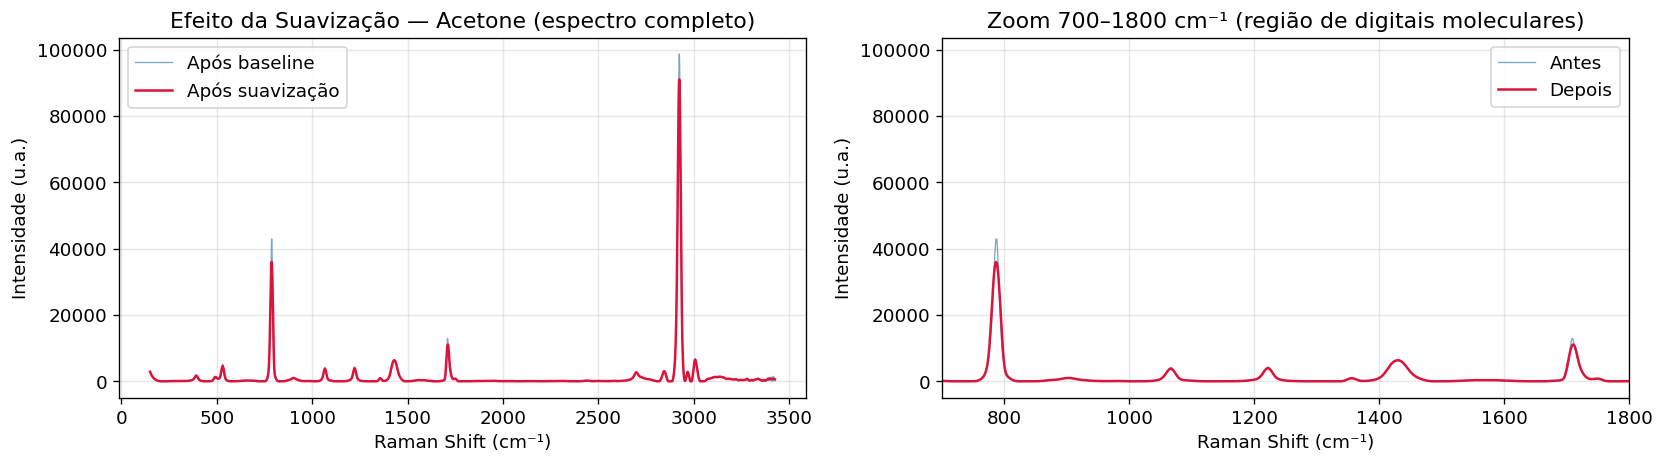

In [7]:
# Aplicar filtro Savitzky-Golay a cada espectro
WINDOW = 25      # comprimento da janela (deve ser ímpar)
POLYORDER = 3    # ordem do polinómio local

X_smooth = np.apply_along_axis(
    lambda row: savgol_filter(row, window_length=WINDOW, polyorder=POLYORDER),
    axis=1,
    arr=X_baseline
)

# Clips de negativos introduzidos pelo filtro nas caudas
X_smooth = np.clip(X_smooth, 0, None)

print(f"   Suavização Savitzky-Golay aplicada.")
print(f"   Janela: {WINDOW} pontos  |  Ordem polinomial: {POLYORDER}")

# Visualizar efeito da suavização num espectro exemplo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pegar num espectro de Acetone como exemplo
idx_ex = np.where(y == 'Acetone')[0][0]

axes[0].plot(raman_shift, X_baseline[idx_ex], color='steelblue', alpha=0.7, lw=0.8, label='Após baseline')
axes[0].plot(raman_shift, X_smooth[idx_ex], color='crimson', lw=1.5, label='Após suavização')
axes[0].set_title('Efeito da Suavização — Acetone (espectro completo)')
axes[0].set_xlabel('Raman Shift (cm⁻¹)')
axes[0].set_ylabel('Intensidade (u.a.)')
axes[0].legend()

# Zoom numa zona de pico
axes[1].plot(raman_shift, X_baseline[idx_ex], color='steelblue', alpha=0.7, lw=0.8, label='Antes')
axes[1].plot(raman_shift, X_smooth[idx_ex], color='crimson', lw=1.5, label='Depois')
axes[1].set_xlim(700, 1800)
axes[1].set_title('Zoom 700–1800 cm⁻¹ (região de digitais moleculares)')
axes[1].set_xlabel('Raman Shift (cm⁻¹)')
axes[1].set_ylabel('Intensidade (u.a.)')
axes[1].legend()

plt.tight_layout()
plt.show()



**Interpretaçao:** O efeito da suavização é visível mas propositadamente subtil. No espectro completo e no zoom da região 700–1800 cm⁻¹ observa-se que os picos mais intensos, nomeadamente o pico a aproximadamente 788 cm⁻¹ (deformação C-C-C simétrica da acetona) e o pico a aproximadamente 2924 cm⁻¹ (estiramento C-H), ficam ligeiramente menos pontiagudos após a suavização, com pequenas oscilações de ruído no topo dos picos a serem atenuadas. A posição e a forma geral dos picos mantém-se inalterada, o que confirma que o filtro está a atuar apenas sobre o ruído de alta frequência sem distorcer a informação espectral relevante.

### 6.4 Normalização de Intensidades

Diferentes amostras do mesmo composto podem ter intensidades absolutas muito diferentes devido a variações nas condições experimentais, pequenas diferenças no foco do laser, no tempo de exposição ou na quantidade de amostra no feixe. Sem normalização, dois espectros do mesmo composto podem parecer distintos apenas por razões instrumentais, o que prejudica qualquer análise comparativa ou modelo de classificação.

**Método escolhido: Normalização pelo máximo por espectro:**

Cada espectro é dividido pelo seu próprio valor máximo, escalando-o para o intervalo [0, 1]. Ao contrário do Z-score ou do Min-Max por coluna, este método atua sobre cada espectro individualmente e preserva as proporções relativas entre todos os seus picos, ou seja, a forma do espectro mantém-se intacta. É essa forma, e não a intensidade absoluta, que contém a informação química relevante.


In [8]:
# Normalização pelo máximo de cada espectro (por linha)
row_max = X_smooth.max(axis=1, keepdims=True)  # máximo de cada espectro

# Evitar divisão por zero (espectros completamente nulos — não deveria acontecer)
row_max[row_max == 0] = 1

X_norm = X_smooth / row_max  # Todos os espectros agora em [0, 1]

print("Normalização concluída.")
print(f"   Intervalo de intensidades após normalização: [{X_norm.min():.4f}, {X_norm.max():.4f}]")
print()

# Verificar que todos os espectros têm máximo = 1
assert np.allclose(X_norm.max(axis=1), 1.0), "Erro: alguns espectros não estão normalizados!"
print("Verificação passada: todos os espectros têm intensidade máxima = 1.0")


Normalização concluída.
   Intervalo de intensidades após normalização: [0.0000, 1.0000]

Verificação passada: todos os espectros têm intensidade máxima = 1.0



### 6.5 Sumário do Pipeline de Pré-processamento

Antes de avançar para a análise exploratória, documentamos o estado da matriz em cada etapa:


In [9]:
stages = {
    'Bruto (original)'         : X_clean,
    'Após correção de baseline': X_baseline,
    'Após suavização (SG)'     : X_smooth,
    'Após normalização'        : X_norm,
}

print(f"{'Etapa':<35s} {'Shape':>12s} {'Min':>10s} {'Max':>10s} {'Média':>10s} {'NaN':>6s}")
print("─" * 90)
for name, mat in stages.items():
    print(f"{name:<35s} {str(mat.shape):>12s} {mat.min():>10.3f} {mat.max():>10.3f} "
          f"{mat.mean():>10.5f} {np.isnan(mat).sum():>6d}")


Etapa                                      Shape        Min        Max      Média    NaN
──────────────────────────────────────────────────────────────────────────────────────────
Bruto (original)                    (1101, 3276)  -2052.829 259315.391 4606.46087      0
Após correção de baseline           (1101, 3276)      0.000 245817.569 1230.33867      0
Após suavização (SG)                (1101, 3276)      0.000 176722.837 1232.02739      0
Após normalização                   (1101, 3276)      0.000      1.000    0.03004      0


## 7. Análise Exploratória dos Dados (EDA)

### 7.1 Estatísticas Descritivas por Composto

Após a normalização dos espectros Raman, foram calculadas estatísticas descritivas para cada composto com o objetivo de obter uma visão geral dos dados e avaliar a variabilidade dos espectros.

Para cada grupo, determinaram-se o número de espectros, a intensidade média, o desvio padrão, os valores mínimo e máximo das intensidades e a posição do pico médio de maior intensidade. Estas métricas permitem resumir o comportamento global dos espectros e identificar diferenças entre compostos.

O cálculo destas estatísticas é importante para verificar a consistência dos dados após o pré-processamento, avaliar o nível de dispersão dos sinais e identificar possíveis variações relevantes entre amostras do mesmo composto.

Além disso, a determinação do pico máximo médio permite identificar a região espectral de maior intensidade de cada composto, podendo evidenciar bandas Raman características associadas à sua estrutura molecular.


In [10]:
# Criar DataFrame com espectros normalizados + compound
df_proc = pd.DataFrame(X_norm, columns=[f"{w:.1f}" for w in raman_shift])
df_proc['compound'] = y

# Estatísticas descritivas globais da intensidade por composto
stats_rows = []
for compound in sorted(df_proc['compound'].unique()):
    sub = df_proc[df_proc['compound'] == compound].drop(columns='compound').values
    # Espectro médio e variância média ao longo de todos os pontos
    stats_rows.append({
        'Composto'          : compound,
        'N espectros'       : len(sub),
        'Intensidade média' : round(sub.mean(), 4),
        'Desvio padrão'     : round(sub.std(), 4),
        'Mínimo'            : round(sub.min(), 4),
        'Máximo'            : round(sub.max(), 4),
        'Pico máximo médio (cm⁻¹)': round(raman_shift[sub.mean(axis=0).argmax()], 1),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Composto')
print("Estatísticas descritivas dos espectros normalizados — Grupo 4:")
print()
print(stats_df.to_string())


Estatísticas descritivas dos espectros normalizados — Grupo 4:

                                N espectros  Intensidade média  Desvio padrão  Mínimo  Máximo  Pico máximo médio (cm⁻¹)
Composto                                                                                                               
1,3-Dimethyl-2-imidazolidinone          109             0.0285         0.0788     0.0     1.0                     765.0
2,2-Dimethoxypropane                    107             0.0412         0.1194     0.0     1.0                    2946.0
2-Propanol                              109             0.0432         0.1282     0.0     1.0                     819.0
4-Methyl-2-pentanone                    100             0.0381         0.1134     0.0     1.0                    2920.0
Acetic acid                             113             0.0200         0.0785     0.0     1.0                    2943.0
Acetone                                 120             0.0153         0.0714     0.0     1.0   


### 7.2 Espectros Médios por Composto (Toda a Gama Espectral)

Após o pré-processamento completo dos dados espectrais, foi calculado o espectro Raman médio de cada composto com o objetivo de comparar os perfis vibracionais característicos entre as diferentes classes químicas.

Para cada composto, foi determinada a média das intensidades normalizadas ao longo de todos os espectros disponíveis, reduzindo o efeito do ruído experimental e evidenciando as bandas Raman mais representativas de cada substância.

Os espectros médios foram representados num único gráfico, permitindo observar diferenças nas posições e intensidades dos principais picos vibracionais. Adicionalmente, foram assinaladas algumas regiões espectrais relevantes associadas a grupos funcionais característicos, como ligações C=O, C≡N e vibrações aromáticas C-H.


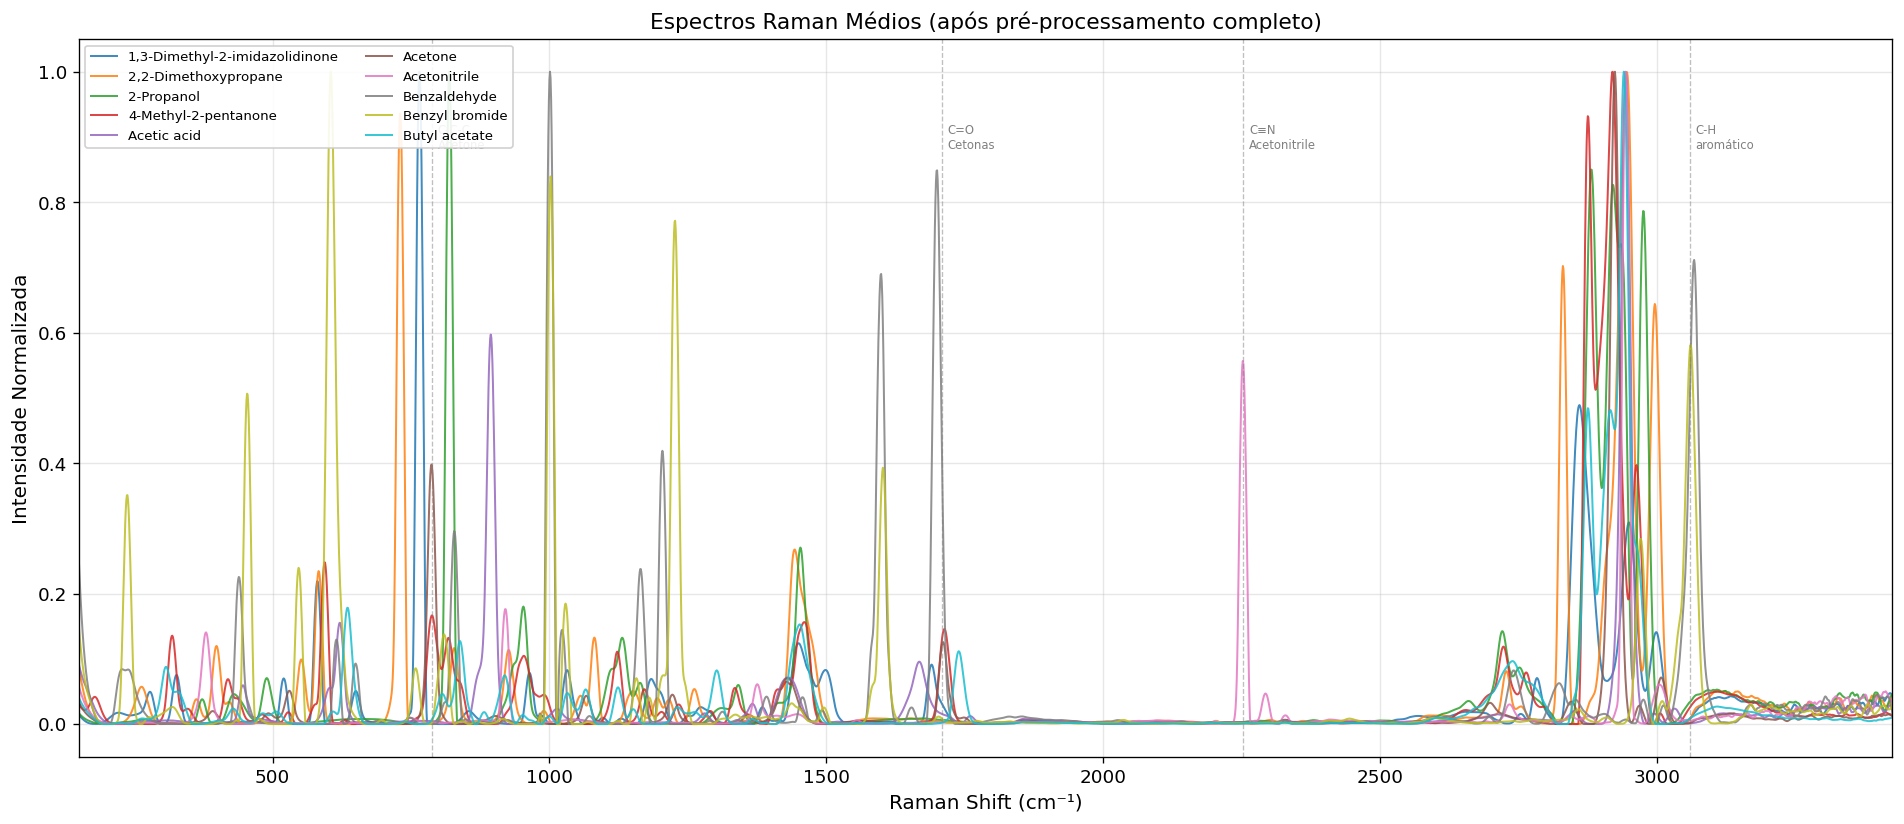

In [11]:
compounds = sorted(df_proc['compound'].unique())
n = len(compounds)
colors = cm.tab10(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(16, 7))

for i, compound in enumerate(compounds):
    sub = df_proc[df_proc['compound'] == compound].drop(columns='compound').values
    mean_spectrum = sub.mean(axis=0)
    ax.plot(raman_shift, mean_spectrum, color=colors[i], label=compound, lw=1.2, alpha=0.85)

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
ax.set_ylabel('Intensidade Normalizada', fontsize=12)
ax.set_title('Espectros Raman Médios (após pré-processamento completo)', fontsize=13)
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9)
ax.set_xlim(raman_shift.min(), raman_shift.max())

# Anotar regiões espectrais chave
for x_pos, label in [(788, 'C-C-C\nAcetone'), (1709, 'C=O\nCetonas'), (2253, 'C≡N\nAcetonitrile'), (3059, 'C-H\naromático')]:
    ax.axvline(x_pos, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax.text(x_pos+10, 0.92, label, fontsize=7, color='gray', va='top')

plt.tight_layout()
plt.show()



**Interpretação:** Os espectros Raman médios apresentados mostram diferenças claras entre os vários compostos, evidenciando que cada substância possui uma assinatura espectral própria. Observam-se picos com posições e intensidades distintas, indicando diferentes modos vibracionais associados às estruturas químicas de cada composto.

Alguns compostos apresentam bandas muito intensas e estreitas, especialmente na região próxima dos 2800–3000 cm⁻¹, associada a vibrações C–H, enquanto outros apresentam sinais mais distribuídos ao longo do espectro. Também se destacam picos específicos em regiões características, como o pico do acetonitrilo em torno de 2250 cm⁻¹ relacionado com a ligação C≡N e bandas associadas a grupos carbonilo (C=O) na região das cetonas.

A região entre 700 e 1800 cm⁻¹ apresenta maior diversidade de bandas e diferenças mais evidentes entre compostos, correspondendo à zona de impressão digital molecular, importante para a identificação química.

De forma geral, os resultados mostram que o pré-processamento permitiu obter espectros mais limpos e comparáveis, mantendo as principais características vibracionais de cada composto e facilitando a distinção entre as diferentes substâncias analisadas.

### 7.3 Espectros Individuais com Banda de Desvio 

Após a análise dos espectros médios, representou-se para cada composto o espectro Raman médio acompanhado do respetivo desvio padrão. O objetivo desta análise é avaliar a variabilidade existente entre os espectros individuais da mesma classe e verificar a consistência dos dados após o pré-processamento.

A linha principal corresponde ao espectro médio do composto, enquanto a região sombreada representa ±1 desvio padrão em cada ponto do espectro. Esta abordagem permite visualizar não apenas o comportamento médio do sinal, mas também o grau de dispersão das intensidades ao longo das diferentes regiões espectrais.


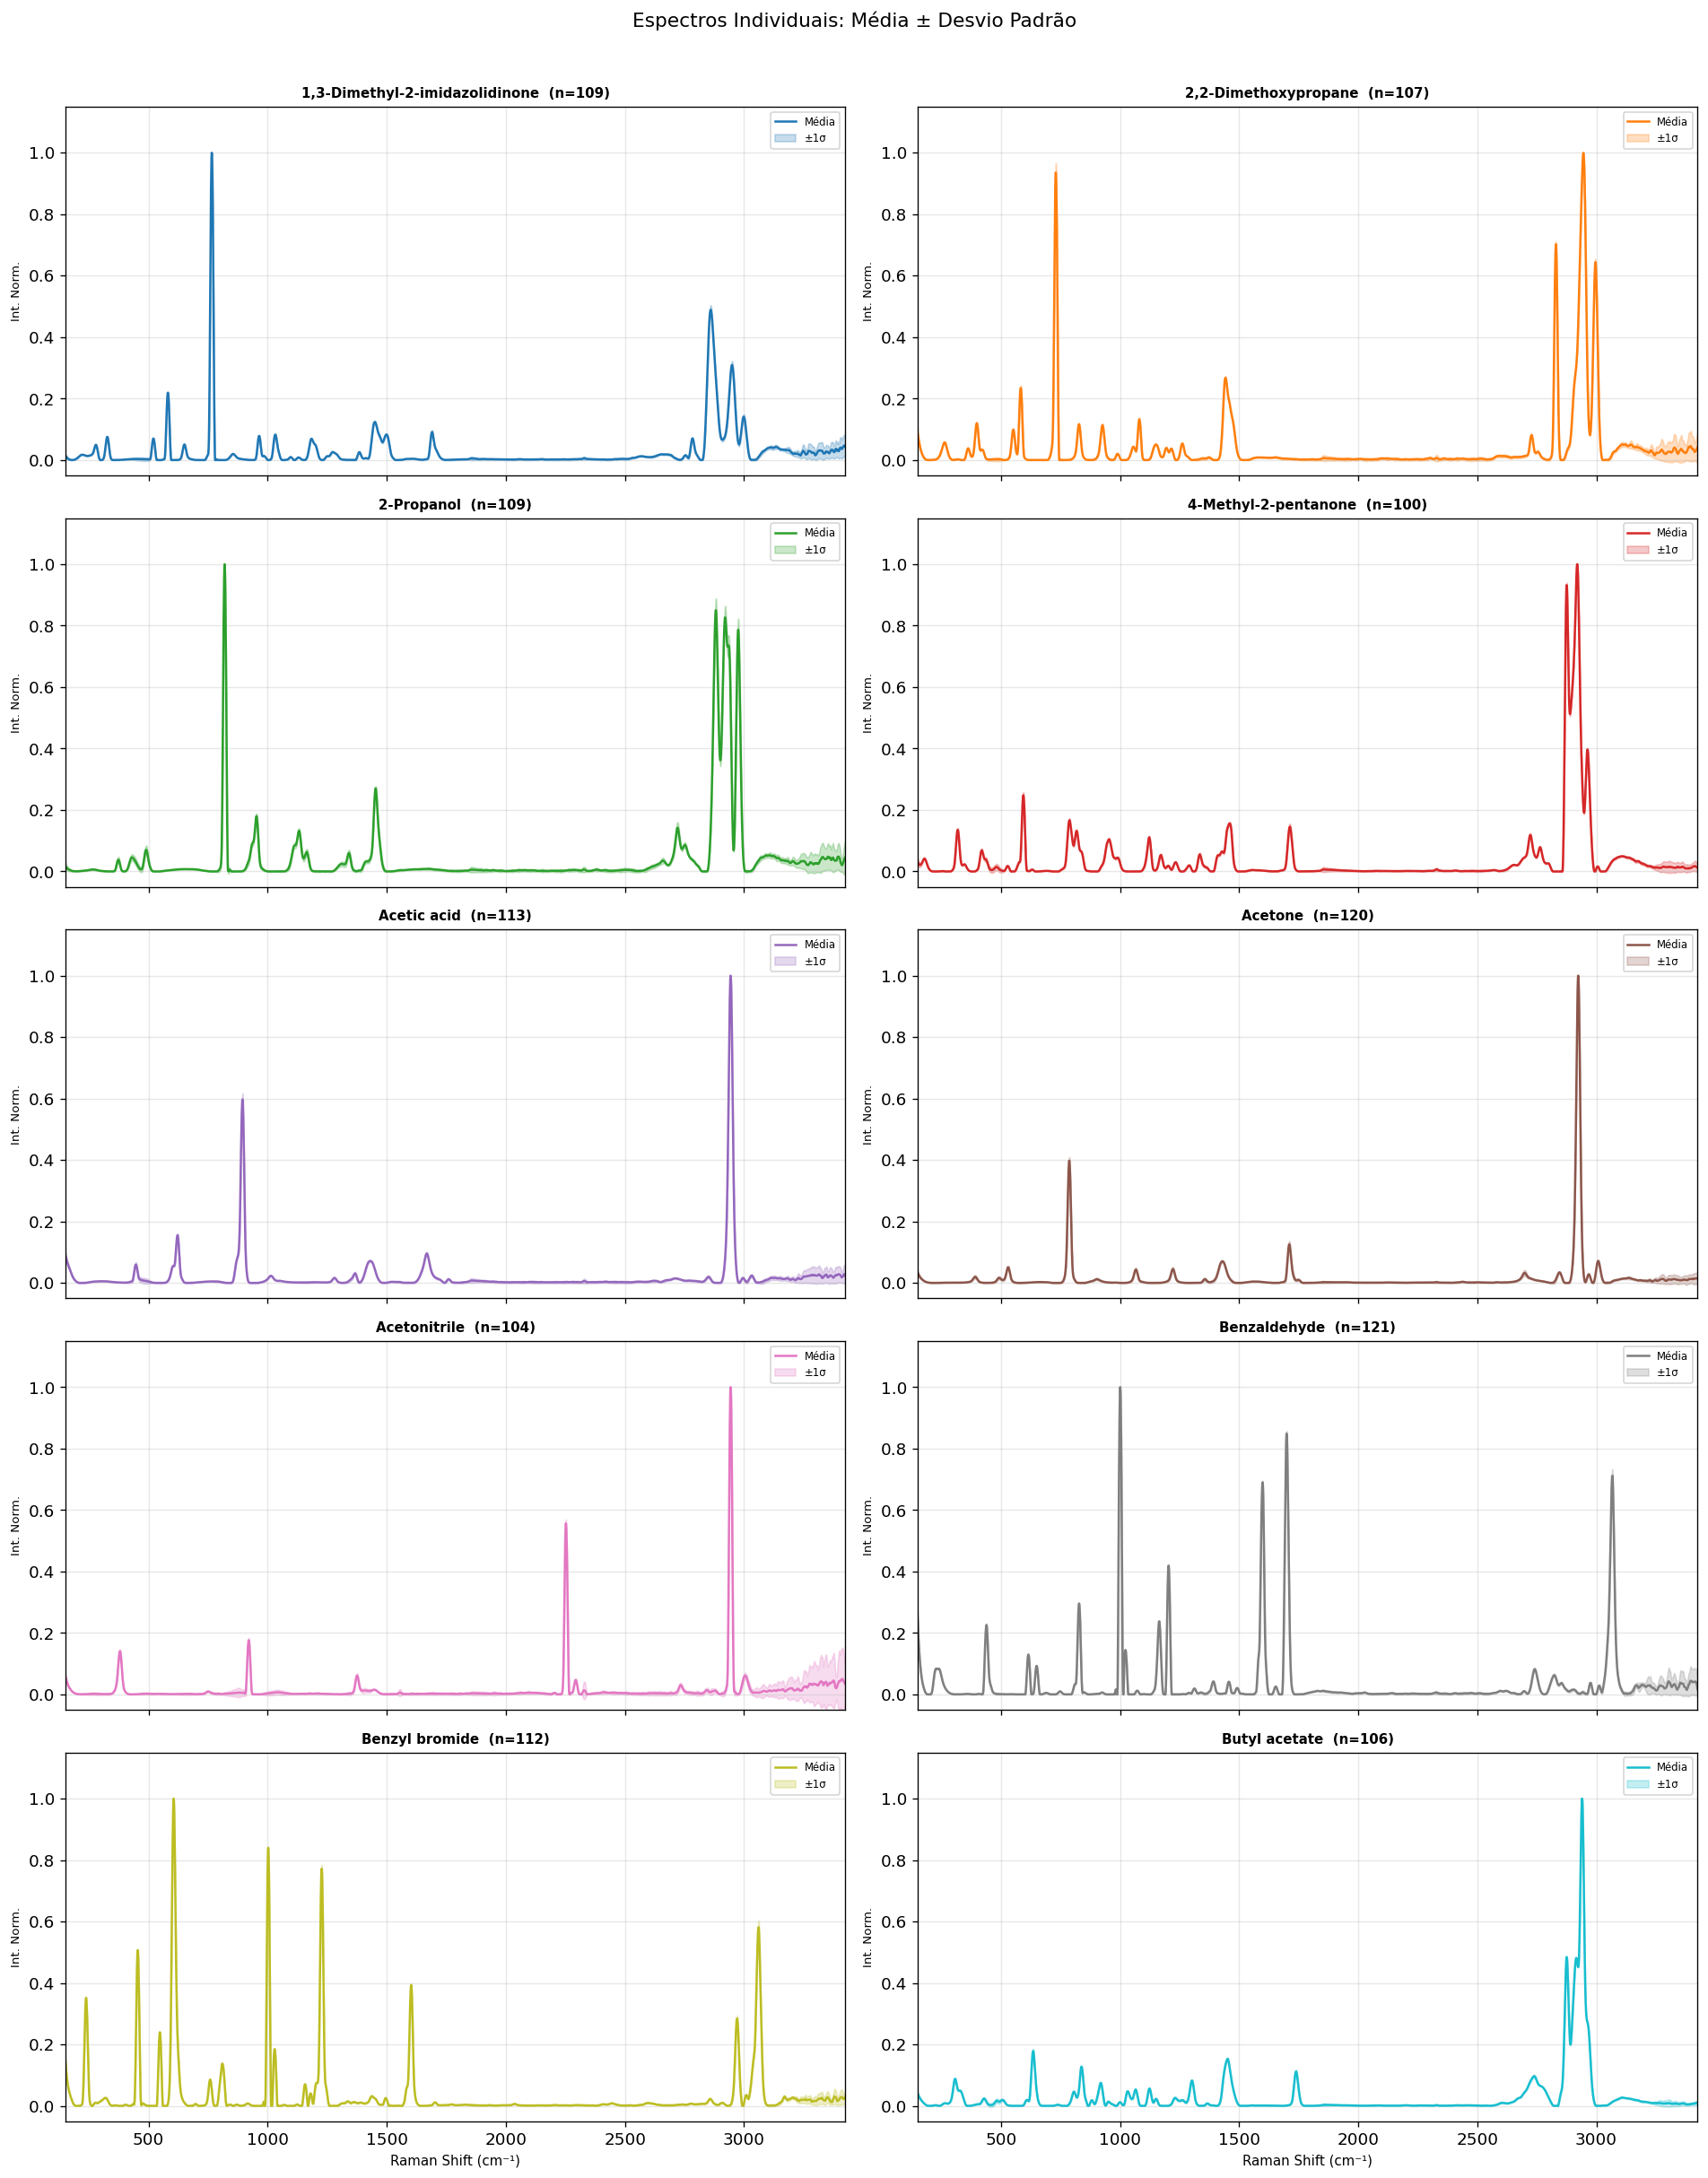

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes_flat = axes.flatten()

for i, compound in enumerate(compounds):
    ax = axes_flat[i]
    sub = df_proc[df_proc['compound'] == compound].drop(columns='compound').values
    mean_spec = sub.mean(axis=0)
    std_spec  = sub.std(axis=0)

    ax.plot(raman_shift, mean_spec, color=colors[i], lw=1.5, label='Média')
    ax.fill_between(raman_shift,
                    mean_spec - std_spec,
                    mean_spec + std_spec,
                    color=colors[i], alpha=0.25, label='±1σ')

    ax.set_title(f'{compound}  (n={len(sub)})', fontsize=9, fontweight='bold')
    ax.set_ylabel('Int. Norm.', fontsize=8)
    ax.set_xlim(raman_shift.min(), raman_shift.max())
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=7, loc='upper right')

# Eixo x apenas na última linha
for ax in axes_flat[-2:]:
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=9)

fig.suptitle('Espectros Individuais: Média ± Desvio Padrão', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretação:** De forma geral, observa-se que a maior parte dos compostos apresenta uma variabilidade relativamente baixa ao longo do espectro, indicando boa consistência entre os espectros individuais após o pré-processamento.

As regiões sombreadas são geralmente estreitas em torno dos principais picos, o que sugere elevada reprodutibilidade experimental e estabilidade dos sinais Raman. Isto é particularmente visível em compostos como a acetona, o ácido acético e o acetonitrilo, onde os principais picos aparecem bem definidos e com pouca dispersão.

Alguns compostos, como o benzaldeído e o brometo de benzilo, apresentam maior número de bandas distribuídas ao longo do espectro, refletindo estruturas moleculares mais complexas e maior diversidade vibracional. Já compostos como a acetona e o acetonitrilo apresentam espectros mais simples, dominados por poucos picos intensos e característicos.

### 7.4 Comparação das Regiões Espectrais Chave

Após a análise global dos espectros, foram selecionadas algumas regiões espectrais de interesse para comparar a distribuição das intensidades médias entre os diferentes compostos. O objetivo desta etapa é avaliar quais as regiões do espectro que apresentam maior capacidade de diferenciação química.

Foram analisadas três regiões principais: a região de impressão digital molecular (700–1800 cm⁻¹), a zona associada a grupos funcionais como C≡N e C=O (1600–1750 cm⁻¹) e a região das vibrações C–H (2800–3100 cm⁻¹).

Para cada composto, calculou-se a intensidade média dos espectros dentro de cada intervalo, representando posteriormente a distribuição dos valores através de boxplots. Esta abordagem permite visualizar não apenas o valor médio das intensidades, mas também a dispersão e variabilidade entre amostras.

Este passo é importante porque permite identificar regiões espectrais mais discriminativas entre compostos, compreender onde existem maiores diferenças de intensidade e avaliar a consistência dos sinais em zonas específicas do espectro. Estas informações são úteis para selecionar regiões relevantes para etapas posteriores de análise estatística e classificação automática.


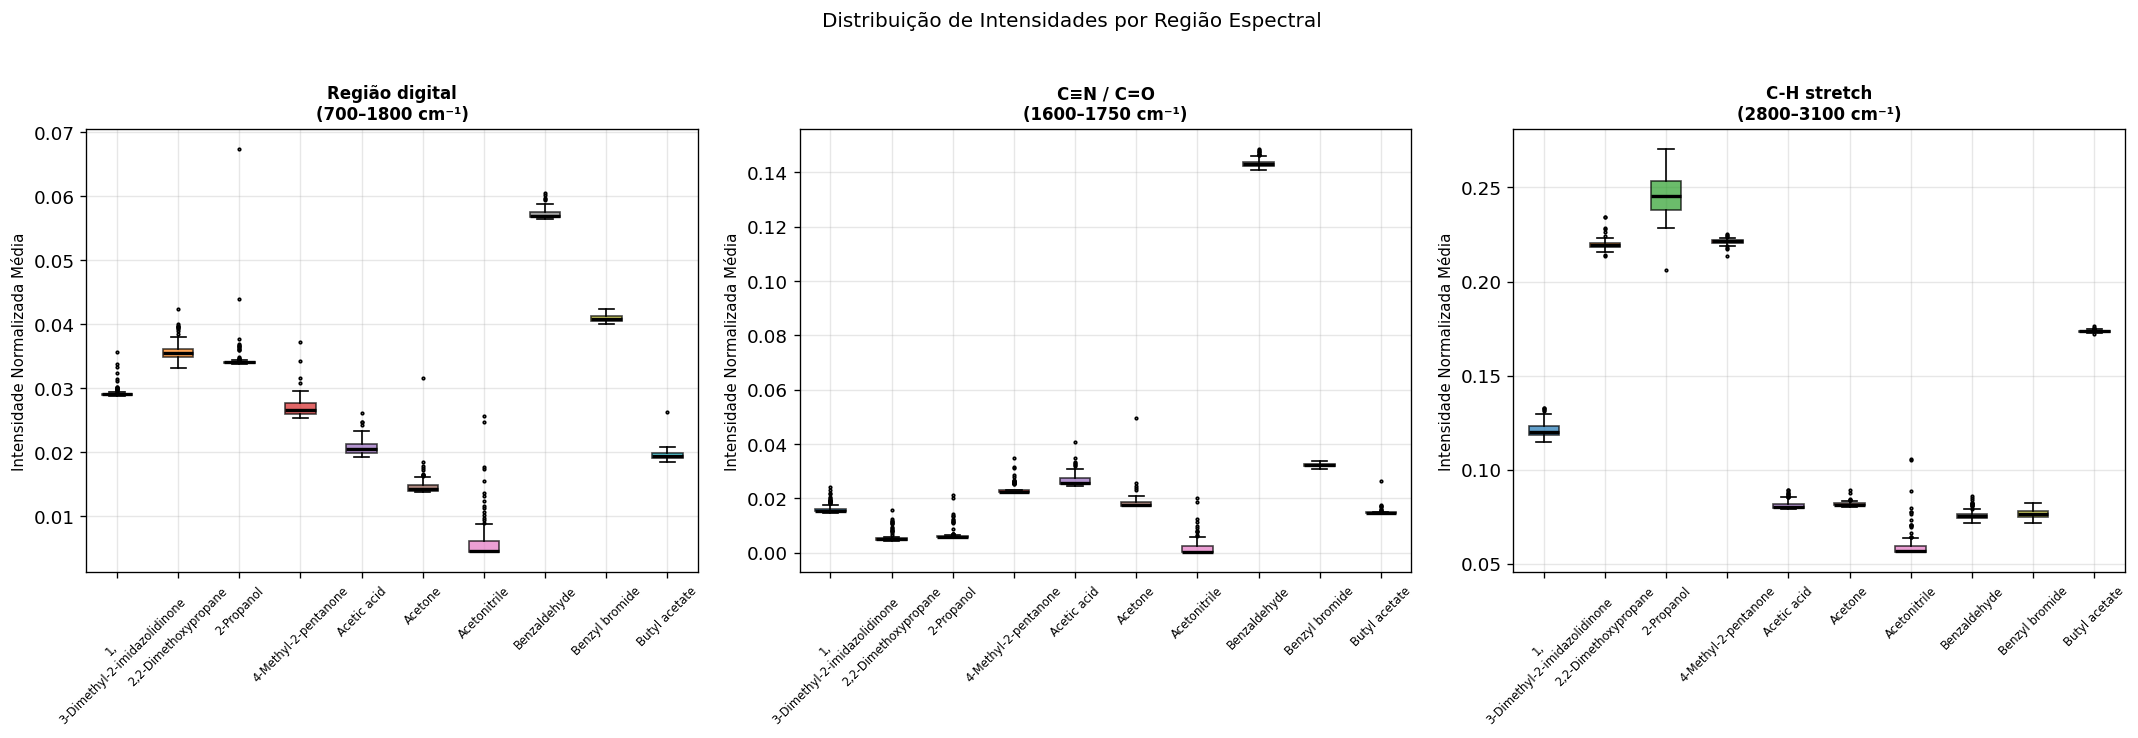

In [13]:
# Regiões de interesse diagnóstico
regions = {
    'Região digital\n(700–1800 cm⁻¹)': (700, 1800),
    'C≡N / C=O\n(1600–1750 cm⁻¹)'  : (1600, 1750),
    'C-H stretch\n(2800–3100 cm⁻¹)' : (2800, 3100),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (region_name, (low, high)) in zip(axes, regions.items()):
    mask = (raman_shift >= low) & (raman_shift <= high)
    region_cols = [f"{w:.1f}" for w in raman_shift[mask]]

    # Intensidade média de cada amostra na região
    region_data = []
    labels_plot = []
    for compound in compounds:
        sub = df_proc[df_proc['compound'] == compound][region_cols].values
        region_data.append(sub.mean(axis=1))
        labels_plot.append(compound.replace(',', ',\n') if len(compound) > 20 else compound)

    bp = ax.boxplot(region_data, labels=labels_plot, patch_artist=True,
                    medianprops={'color': 'black', 'lw': 2},
                    flierprops={'marker': '.', 'markersize': 3})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(region_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Intensidade Normalizada Média', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=45)

plt.suptitle('Distribuição de Intensidades por Região Espectral', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Interpretação:** De forma geral, observa-se que a maioria dos compostos apresenta uma variabilidade reduzida nas intensidades normalizadas médias, evidenciada por caixas compactas e whiskers curtos, o que indica boa reprodutibilidade entre espectros individuais após o pré-processamento.

Na região fingerprint (700–1800 cm⁻¹), os compostos mostram distribuições geralmente estreitas, com exceção da acetona, que apresenta uma dispersão notavelmente superior e um maior número de outliers, sugerindo maior variabilidade espectral nesta janela de número de onda. O acetonitrilo destaca-se nesta região pela sua intensidade normalizada média significativamente superior à dos restantes compostos, com uma distribuição bastante concentrada, o que o torna facilmente discriminável.

                   
Na região C≡N / C=O (1600–1750 cm⁻¹), o benzaldeído sobressai de forma inequívoca, apresentando uma intensidade média cerca de quatro a cinco vezes superior à dos demais compostos, comportamento esperado dado o seu grupo carbonilo aromático altamente absorvente. Em contraste, compostos como o 2-propanol e o 2,2-dimetoxipropano registam valores próximos de zero nesta região, revelando ausência de grupos funcionais com absorção relevante nesta janela espectral.


                     
Na região C-H stretch (2800–3100 cm⁻¹), destacam-se o 2-propanol e o 2,2-dimetoxipropano com as intensidades mais elevadas, consistentes com as suas estruturas moleculares ricas em ligações C-H. Por outro lado, compostos como o acetonitrilo e o benzaldeído apresentam intensidades reduzidas nesta região, refletindo menor densidade de grupos C-H nas suas estruturas. De um modo geral, as distribuições nesta região são as mais compactas de todo o conjunto analisado, sugerindo uma estabilidade de sinal particularmente elevada na região de elongamento C-H.

## 8. Comparação Visual dos Espectros Médios e Bandas Raman Mais Relevantes

Depois de concluído o pré-processamento e a análise exploratória inicial, avançamos para uma comparação mais detalhada dos espectros médios. Esta etapa é importante porque permite perceber, antes de aplicar métodos multivariados, quais são as regiões do espectro que mais contribuem para distinguir os compostos.

Nesta secção são analisadas especialmente as bandas mais intensas de cada composto e a região de impressão digital molecular, aproximadamente entre 650 e 1800 cm⁻¹. Esta zona é particularmente relevante em espectroscopia Raman porque concentra muitos modos vibracionais associados a ligações C–C, C–O, C–N, C=O e vibrações de anéis aromáticos.


In [14]:
# ── 8.1  Espectro médio de cada composto ─────────────────────────────────────
# Nesta etapa reaproveitamos os dados já pré-processados anteriormente:
#   df_proc      → espectros normalizados + coluna compound
#   X_norm       → matriz numérica normalizada
#   raman_shift  → eixo Raman Shift em cm⁻¹
#   y            → vetor com o nome do composto de cada espectro

mean_spectra = {}
std_spectra = {}

for compound in compounds:
    sub = df_proc[df_proc['compound'] == compound].drop(columns='compound').values
    mean_spectra[compound] = sub.mean(axis=0)
    std_spectra[compound] = sub.std(axis=0)

print(f"Número de compostos analisados: {len(mean_spectra)}")
print("Compostos:")
for compound in mean_spectra:
    print(f"  → {compound}")


Número de compostos analisados: 10
Compostos:
  → 1,3-Dimethyl-2-imidazolidinone
  → 2,2-Dimethoxypropane
  → 2-Propanol
  → 4-Methyl-2-pentanone
  → Acetic acid
  → Acetone
  → Acetonitrile
  → Benzaldehyde
  → Benzyl bromide
  → Butyl acetate


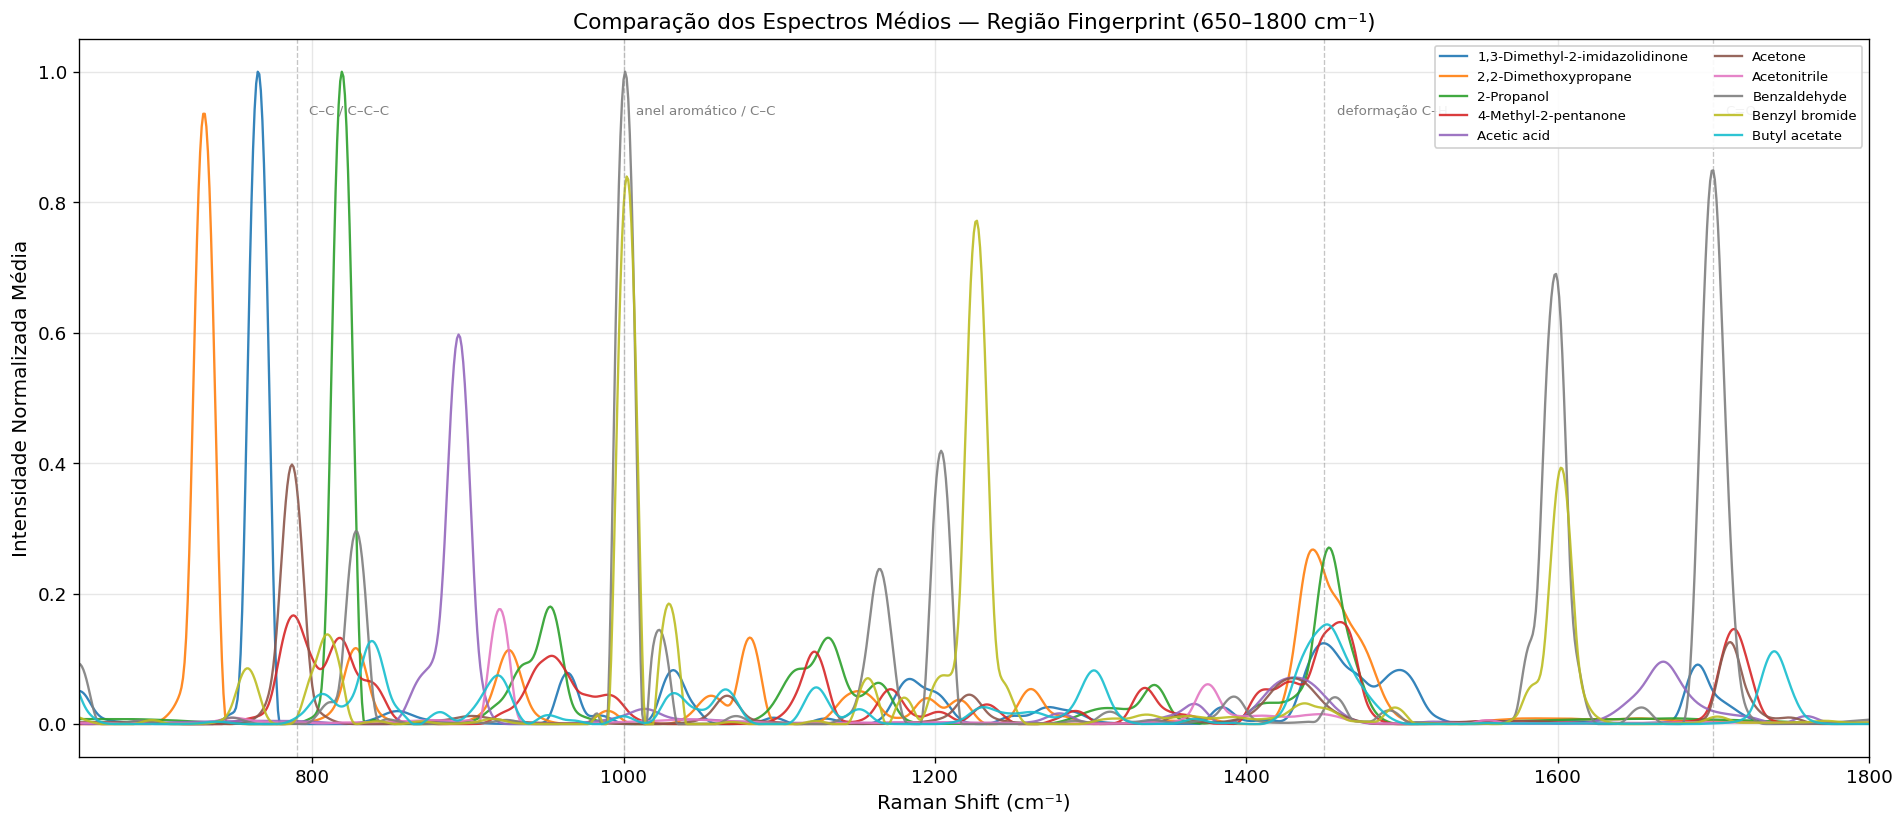

In [15]:
# ── 8.2  Comparação dos espectros médios na região fingerprint ───────────────
fingerprint_mask = (raman_shift >= 650) & (raman_shift <= 1800)

fig, ax = plt.subplots(figsize=(16, 7))

for i, compound in enumerate(compounds):
    ax.plot(
        raman_shift[fingerprint_mask],
        mean_spectra[compound][fingerprint_mask],
        color=colors[i],
        lw=1.4,
        alpha=0.9,
        label=compound
    )

ax.set_title('Comparação dos Espectros Médios — Região Fingerprint (650–1800 cm⁻¹)', fontsize=13)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
ax.set_ylabel('Intensidade Normalizada Média', fontsize=12)
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
ax.set_xlim(650, 1800)

# Regiões químicas aproximadas que costumam ser relevantes nos compostos do grupo
for x_pos, label in [
    (790, 'C–C / C–C–C'),
    (1000, 'anel aromático / C–C'),
    (1450, 'deformação C–H'),
    (1700, 'C=O')
]:
    ax.axvline(x_pos, color='gray', lw=0.8, linestyle='--', alpha=0.45)
    ax.text(x_pos + 8, 0.95, label, fontsize=8, color='gray', va='top')

plt.tight_layout()
plt.show()


**Interpretação:** A comparação dos espectros médios na região fingerprint confirma que os compostos não diferem apenas pela intensidade global, mas sobretudo pela posição e pela combinação dos picos. As regiões entre aproximadamente 700–900 cm⁻¹, perto de 1000 cm⁻¹, em torno de 1450 cm⁻¹ e entre 1600–1750 cm⁻¹ são particularmente informativas no gráfico. A zona próxima de 1000 cm⁻¹ e a região 1600–1700 cm⁻¹ ajudam a destacar compostos com contribuição aromática, como o Benzaldeído e o Brometo de benzilo. Já os compostos com grupos carbonilo ou ligações C–O/C–C apresentam diferenças mais subtis entre si, o que explica porque alguns não ficam completamente isolados apenas por inspeção visual.

Também se observa que alguns compostos têm picos muito intensos e estreitos, enquanto outros apresentam vários picos de intensidade intermédia. Isto é relevante porque a análise multivariada não depende de um único pico, mas sim da assinatura completa do espectro. No caso do Acetonitrilo, a banda C≡N característica situa-se fora desta janela, perto de 2250 cm⁻¹; por isso, neste gráfico específico da região 650–1800 cm⁻¹, a interpretação deve concentrar-se nas diferenças da fingerprint e não nessa banda.


In [16]:
# ── 8.3  Identificação automática das bandas mais intensas por composto ──────

peak_rows = []

for compound in compounds:
    spectrum = mean_spectra[compound]
    
    # Procurar máximos locais no espectro médio.
    # distance evita contar vários pontos do mesmo pico.
    peaks, properties = find_peaks(spectrum, height=0.08, distance=35)
    
    # Ordenar os picos por intensidade decrescente
    top_peaks = sorted(peaks, key=lambda idx: spectrum[idx], reverse=True)[:6]
    
    for rank, idx_peak in enumerate(top_peaks, start=1):
        peak_rows.append({
            'Composto': compound,
            'Rank': rank,
            'Raman Shift (cm⁻¹)': round(raman_shift[idx_peak], 1),
            'Intensidade média': round(float(spectrum[idx_peak]), 4)
        })

peaks_df = pd.DataFrame(peak_rows)

print("Bandas Raman mais intensas por composto — espectros médios normalizados:")
print()
print(peaks_df.to_string(index=False))


Bandas Raman mais intensas por composto — espectros médios normalizados:

                      Composto  Rank  Raman Shift (cm⁻¹)  Intensidade média
1,3-Dimethyl-2-imidazolidinone     1               765.0             1.0000
1,3-Dimethyl-2-imidazolidinone     2              2860.0             0.4889
1,3-Dimethyl-2-imidazolidinone     3              2949.0             0.3091
1,3-Dimethyl-2-imidazolidinone     4               581.0             0.2191
1,3-Dimethyl-2-imidazolidinone     5              2999.0             0.1408
1,3-Dimethyl-2-imidazolidinone     6              1450.0             0.1239
          2,2-Dimethoxypropane     1              2946.0             0.9993
          2,2-Dimethoxypropane     2               730.0             0.9355
          2,2-Dimethoxypropane     3              2830.0             0.7021
          2,2-Dimethoxypropane     4              2996.0             0.6440
          2,2-Dimethoxypropane     5              1443.0             0.2675
          2,2-

In [17]:
# ── 8.4  Tabela resumida: principais bandas por composto ─────────────────────
summary_rows = []

for compound in compounds:
    sub = peaks_df[peaks_df['Composto'] == compound].copy()
    bandas = ', '.join([f"{v:.0f}" for v in sub['Raman Shift (cm⁻¹)'].values])
    summary_rows.append({
        'Composto': compound,
        'Principais bandas Raman (cm⁻¹)': bandas
    })

band_summary_df = pd.DataFrame(summary_rows).set_index('Composto')
print(band_summary_df.to_string())


                                   Principais bandas Raman (cm⁻¹)
Composto                                                         
1,3-Dimethyl-2-imidazolidinone   765, 2860, 2949, 581, 2999, 1450
2,2-Dimethoxypropane             2946, 730, 2830, 2996, 1443, 583
2-Propanol                       819, 2881, 2920, 2975, 1453, 953
4-Methyl-2-pentanone             2920, 2875, 2963, 594, 788, 1460
Acetic acid                                  2943, 894, 621, 1668
Acetone                                           2924, 787, 1711
Acetonitrile                                 2943, 2252, 920, 380
Benzaldehyde                    1001, 1700, 3067, 1599, 1204, 828
Benzyl bromide                   605, 1002, 1227, 3061, 454, 1602
Butyl acetate                    2940, 2875, 635, 1452, 838, 1739


**Interpretação:** A tabela das bandas mais intensas complementa o gráfico anterior porque transforma a observação visual em valores de Raman Shift concretos. Esta etapa é útil para evitar uma leitura apenas qualitativa: quando duas substâncias apresentam picos dominantes em zonas semelhantes, é expectável que possam surgir mais próximas em PCA ou clustering; quando uma substância apresenta picos dominantes em regiões pouco partilhadas, tende a separar-se melhor.

A leitura desta tabela deve, no entanto, ser feita com alguma cautela. Como os espectros foram normalizados, os picos listados representam as bandas mais importantes dentro de cada composto, mas não devem ser interpretados como intensidades absolutas comparáveis entre compostos. O objetivo principal aqui é identificar regiões discriminantes do espectro que ajudam a explicar os agrupamentos obtidos nas secções seguintes.


---

## 9. Redução de Dimensionalidade

Os espectros Raman têm milhares de variáveis, uma por cada valor de Raman Shift. Trabalhar diretamente num espaço com tantas dimensões torna difícil visualizar relações entre amostras e perceber se os compostos se separam naturalmente.

Por isso, aplicamos métodos de redução de dimensionalidade. O objetivo é representar cada espectro num espaço mais pequeno, mantendo o máximo possível da informação relevante. Nesta secção são usados PCA como método principal e t-SNE/UMAP como métodos opcionais de visualização não linear.


In [18]:
# ── 9.1  Preparação da matriz para análise multivariada ──────────────────────
# X_norm já está normalizado por espectro. Para PCA e clustering, aplicamos ainda
# uma padronização por variável para que regiões com maior variância absoluta não dominem sozinhas.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

print(f"Matriz original normalizada : {X_norm.shape}")
print(f"Matriz após padronização    : {X_scaled.shape}")
print(f"Média global após scaling   : {X_scaled.mean():.4f}")
print(f"Desvio padrão global        : {X_scaled.std():.4f}")


Matriz original normalizada : (1101, 3276)
Matriz após padronização    : (1101, 3276)
Média global após scaling   : 0.0000
Desvio padrão global        : 1.0000


In [19]:
# ── 9.2  PCA — redução para componentes principais ───────────────────────────
pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

print("Variância explicada pelo PCA:")
for i, (var, cum) in enumerate(zip(explained, cumulative), start=1):
    print(f"  PC{i:<2d}: {var*100:6.2f}%   | acumulada: {cum*100:6.2f}%")


Variância explicada pelo PCA:
  PC1 :  24.26%   | acumulada:  24.26%
  PC2 :  16.76%   | acumulada:  41.02%
  PC3 :  10.52%   | acumulada:  51.54%
  PC4 :   9.31%   | acumulada:  60.84%
  PC5 :   7.96%   | acumulada:  68.80%
  PC6 :   6.09%   | acumulada:  74.89%
  PC7 :   5.29%   | acumulada:  80.18%
  PC8 :   4.65%   | acumulada:  84.83%
  PC9 :   3.96%   | acumulada:  88.79%
  PC10:   2.77%   | acumulada:  91.56%


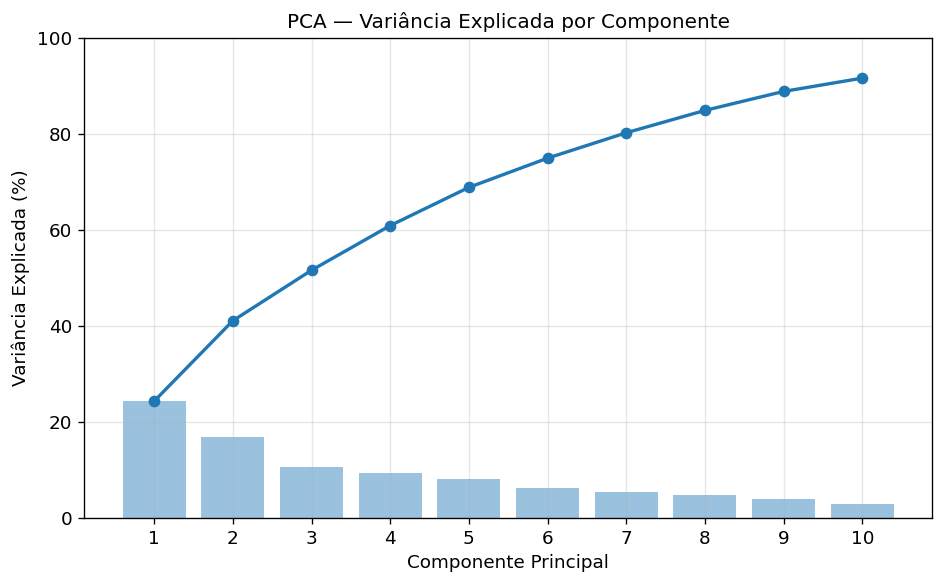

In [20]:
# ── 9.3  Gráfico da variância explicada acumulada ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

pcs = np.arange(1, len(cumulative) + 1)
ax.plot(pcs, cumulative * 100, marker='o', lw=2)
ax.bar(pcs, explained * 100, alpha=0.45)

ax.set_title('PCA — Variância Explicada por Componente', fontsize=12)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variância Explicada (%)')
ax.set_xticks(pcs)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


**Leitura do resultado:** A primeira componente principal explica cerca de 24,3% da variância e a segunda cerca de 16,8%, totalizando aproximadamente 41% nas duas primeiras componentes. Isto é suficiente para visualizar padrões importantes, mas não representa toda a informação espectral. Por isso, o gráfico PC1–PC2 deve ser usado como uma representação resumida e não como prova definitiva de separação total entre compostos.

A curva acumulada mostra que a variância explicada continua a aumentar de forma relevante até às componentes seguintes, chegando a mais de 90% nas primeiras dez componentes. Esta observação justifica o uso das primeiras dez PCs no clustering: reduz-se a dimensionalidade e o ruído, mas mantém-se uma parte substancial da informação dos espectros.


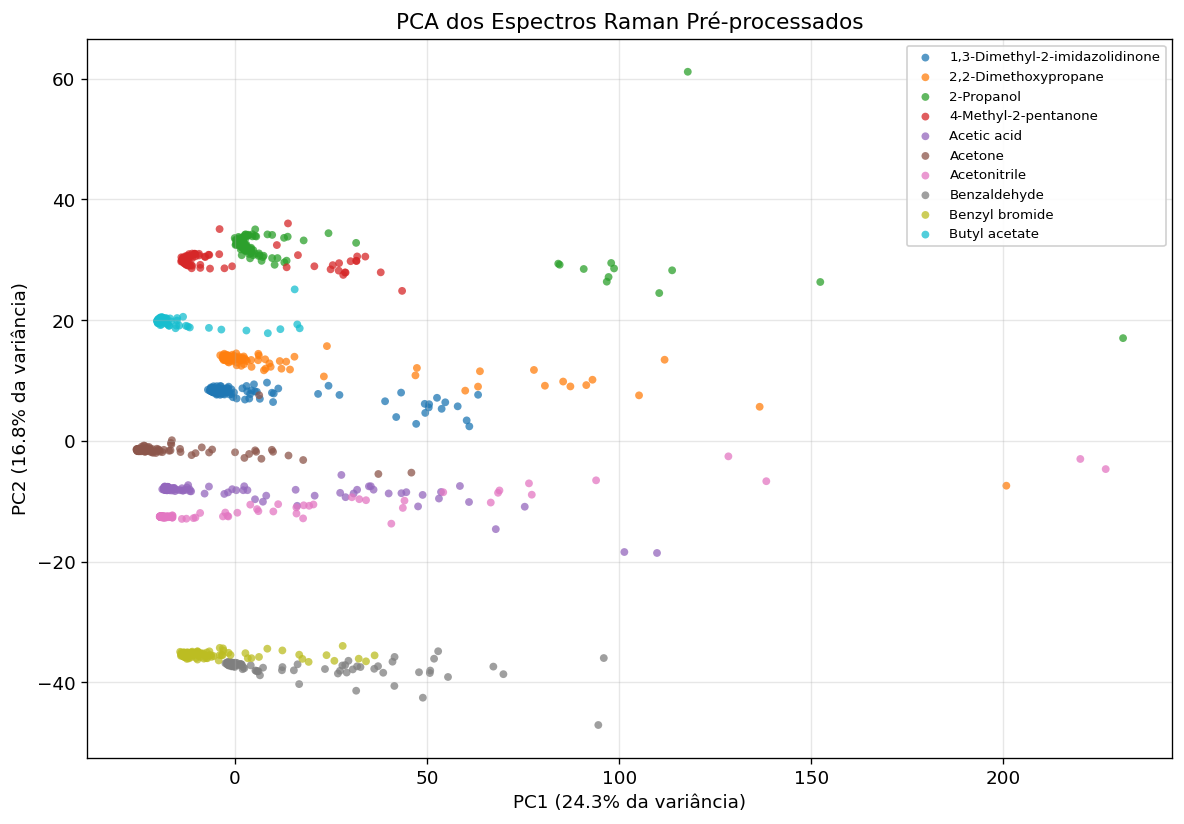

In [21]:
# ── 9.4  Visualização PCA em 2 dimensões ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for i, compound in enumerate(compounds):
    mask = (y == compound)
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=22,
        alpha=0.75,
        color=colors[i],
        label=compound,
        edgecolor='none'
    )

ax.set_title('PCA dos Espectros Raman Pré-processados', fontsize=13)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% da variância)")
ax.legend(loc='best', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()


**Interpretação:** O gráfico PCA mostra uma separação visível entre vários compostos, sobretudo ao longo da PC2, onde se formam faixas relativamente distintas. Isto indica que as diferenças espectrais captadas pelas duas primeiras componentes já são suficientes para organizar parte dos compostos em regiões próprias do espaço multivariado.

Mesmo assim, a separação não é perfeita. Alguns grupos aparecem próximos entre si e há amostras mais afastadas na direção positiva da PC1. Esta leitura é importante: como o plano PC1–PC2 representa apenas uma parte da variabilidade total, alguma sobreposição visual não significa necessariamente que os compostos sejam indistinguíveis. Parte da separação pode estar nas componentes seguintes, razão pela qual o clustering foi aplicado usando mais componentes principais e não apenas as duas mostradas no gráfico.

Quimicamente, esta distribuição é coerente com a ideia de que os espectros Raman combinam vários tipos de informação: bandas da região fingerprint, vibrações associadas a grupos funcionais e diferenças na forma global do espectro. Assim, compostos com algumas semelhanças estruturais podem ficar próximos em certas direções do PCA, mas ainda assim serem separados noutras componentes.


In [22]:
# ── 9.5  Bandas Raman com maior peso nas duas primeiras componentes ──────────
# Os loadings indicam quais variáveis espectrais mais contribuem para cada PC.

loading_rows = []

for pc_idx in [0, 1]:
    loadings = pca.components_[pc_idx]
    top_idx = np.argsort(np.abs(loadings))[::-1][:12]
    
    for rank, idx_var in enumerate(top_idx, start=1):
        loading_rows.append({
            'Componente': f'PC{pc_idx + 1}',
            'Rank': rank,
            'Raman Shift (cm⁻¹)': round(raman_shift[idx_var], 1),
            'Loading': round(float(loadings[idx_var]), 4),
            '|Loading|': round(float(abs(loadings[idx_var])), 4)
        })

loadings_df = pd.DataFrame(loading_rows)
print("Variáveis Raman com maior contribuição para PC1 e PC2:")
print()
print(loadings_df.to_string(index=False))


Variáveis Raman com maior contribuição para PC1 e PC2:

Componente  Rank  Raman Shift (cm⁻¹)  Loading  |Loading|
       PC1     1              2321.0   0.0330     0.0330
       PC1     2              2320.0   0.0327     0.0327
       PC1     3              2322.0   0.0324     0.0324
       PC1     4              3333.0   0.0320     0.0320
       PC1     5              3332.0   0.0320     0.0320
       PC1     6              2509.0   0.0319     0.0319
       PC1     7              3334.0   0.0319     0.0319
       PC1     8              2508.0   0.0319     0.0319
       PC1     9              3331.0   0.0319     0.0319
       PC1    10              2337.0   0.0319     0.0319
       PC1    11              3326.0   0.0319     0.0319
       PC1    12              2510.0   0.0319     0.0319
       PC2     1              2674.0   0.0369     0.0369
       PC2     2              2675.0   0.0369     0.0369
       PC2     3              2673.0   0.0369     0.0369
       PC2     4              26

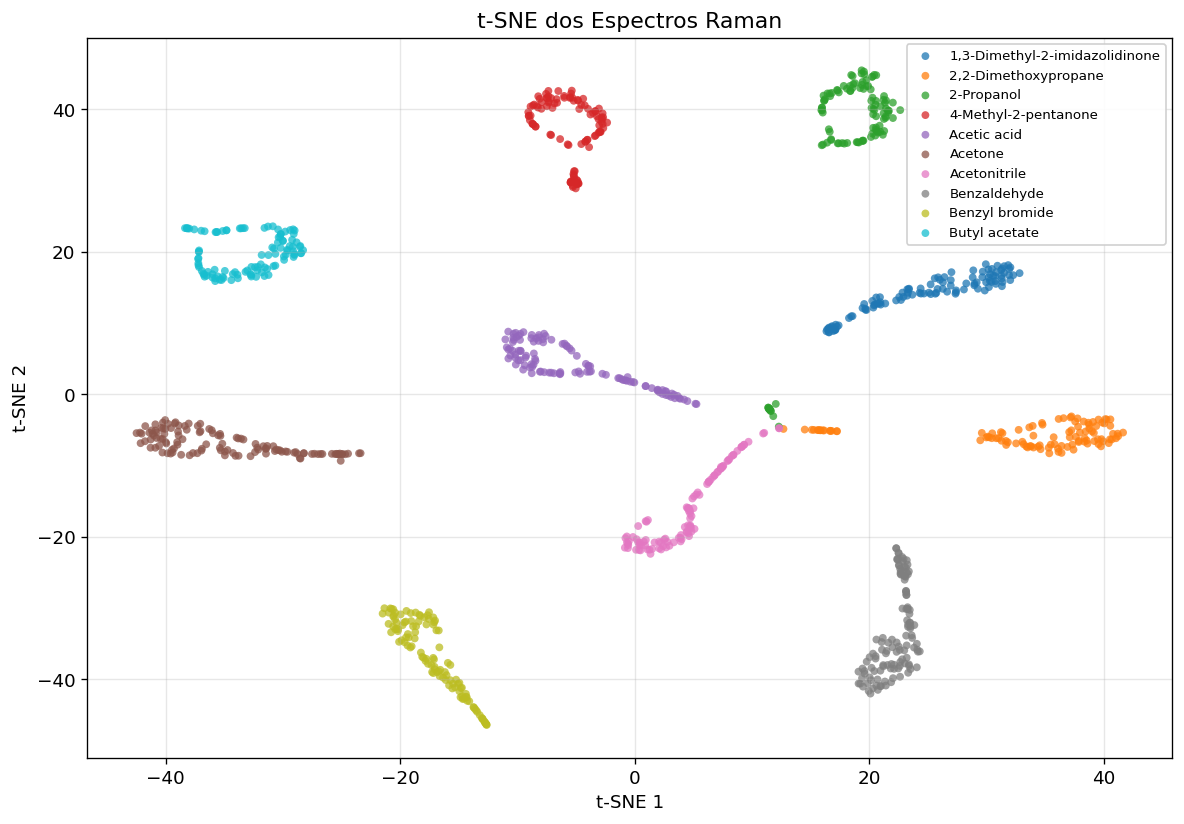

In [23]:
# ── 9.6  t-SNE opcional ───────────────────────────────────────────────────────
# O t-SNE pode ser demorado, por isso fica desligado por defeito.
# Para correr, alterar RUN_TSNE para True.

RUN_TSNE = True

if RUN_TSNE:
    # Para acelerar, aplicamos t-SNE sobre as primeiras PCs em vez das 3276 variáveis originais.
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE
    )
    X_tsne = tsne.fit_transform(X_pca[:, :10])
    
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, compound in enumerate(compounds):
        mask = (y == compound)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=22, alpha=0.75,
                   color=colors[i], label=compound, edgecolor='none')
    
    ax.set_title('t-SNE dos Espectros Raman')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()
else:
    print("t-SNE não foi executado para evitar tempos de cálculo longos.")
    print("Para ativar: alterar RUN_TSNE = True nesta célula.")


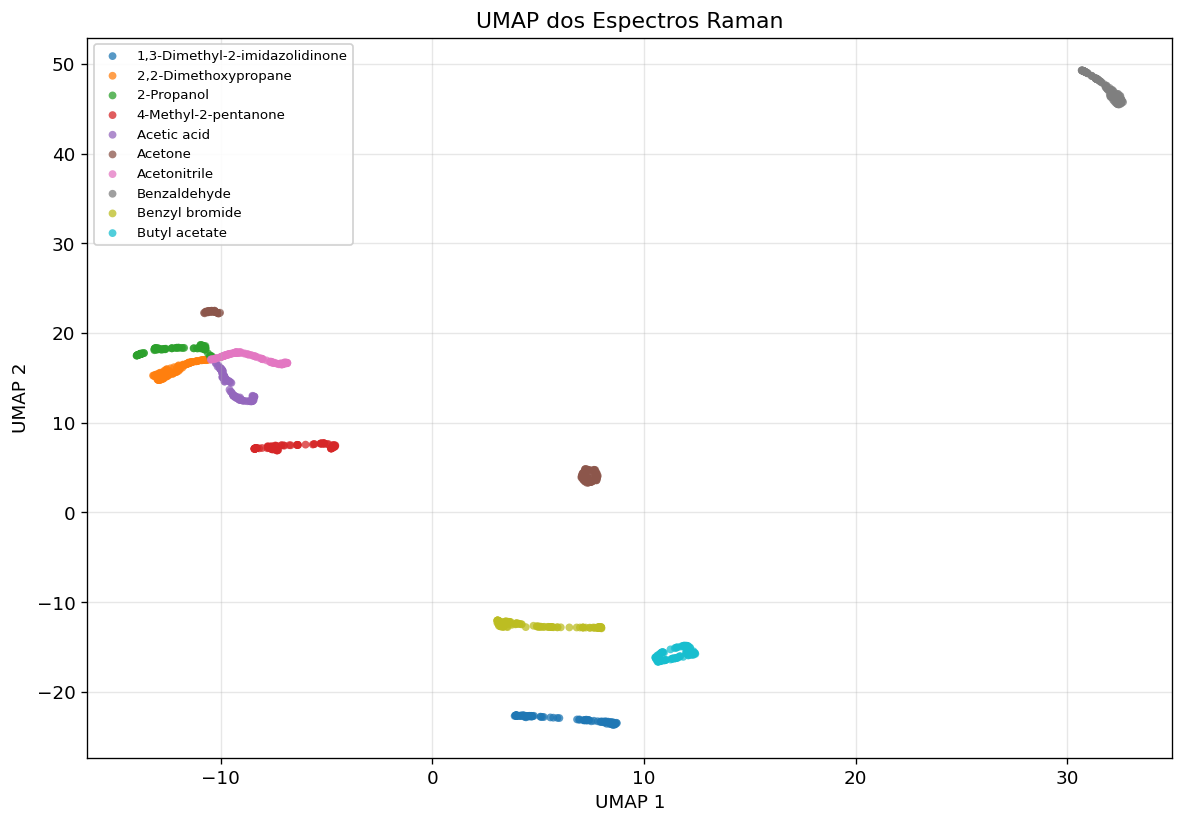

In [24]:
# ── 9.7  UMAP opcional ────────────────────────────────────────────────────────
# O UMAP exige a biblioteca umap-learn. Se não estiver instalada:
#     %pip install umap-learn

RUN_UMAP = True

if RUN_UMAP:
    try:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=20,
            min_dist=0.1,
            random_state=RANDOM_STATE
        )
        X_umap = reducer.fit_transform(X_pca[:, :10])
        
        fig, ax = plt.subplots(figsize=(10, 7))
        for i, compound in enumerate(compounds):
            mask = (y == compound)
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=22, alpha=0.75,
                       color=colors[i], label=compound, edgecolor='none')
        
        ax.set_title('UMAP dos Espectros Raman')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("A biblioteca umap-learn não está instalada.")
        print("Instalar com: %pip install umap-learn")
else:
    print("UMAP não foi executado por defeito.")
    print("Para ativar: instalar umap-learn e alterar RUN_UMAP = True.")


---

## 10. Clustering dos Espectros

Depois de visualizar os dados com PCA, aplicamos clustering para verificar se os espectros se agrupam naturalmente sem usar as etiquetas dos compostos. Esta análise é não supervisionada: o algoritmo não sabe previamente qual é o composto de cada amostra.

A qualidade dos grupos obtidos é avaliada com métricas internas, como o silhouette score, e depois comparada com os nomes reais dos compostos apenas para interpretar os resultados.


In [25]:
# ── 10.1  Escolha do número de clusters com KMeans ───────────────────────────
# Usamos as primeiras PCs porque concentram grande parte da informação e reduzem ruído.

X_cluster = X_pca[:, :10]

k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels_k))

cluster_eval_df = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertias,
    'Silhouette': silhouettes
})

print("Avaliação de diferentes valores de k:")
print(cluster_eval_df.to_string(index=False))


Avaliação de diferentes valores de k:
 k      Inertia  Silhouette
 2 2.734442e+06    0.335136
 3 2.242821e+06    0.278853
 4 1.876050e+06    0.306550
 5 1.548487e+06    0.396633
 6 1.286281e+06    0.473326
 7 1.049035e+06    0.546076
 8 8.330385e+05    0.610906
 9 6.849292e+05    0.673420
10 5.405594e+05    0.713403


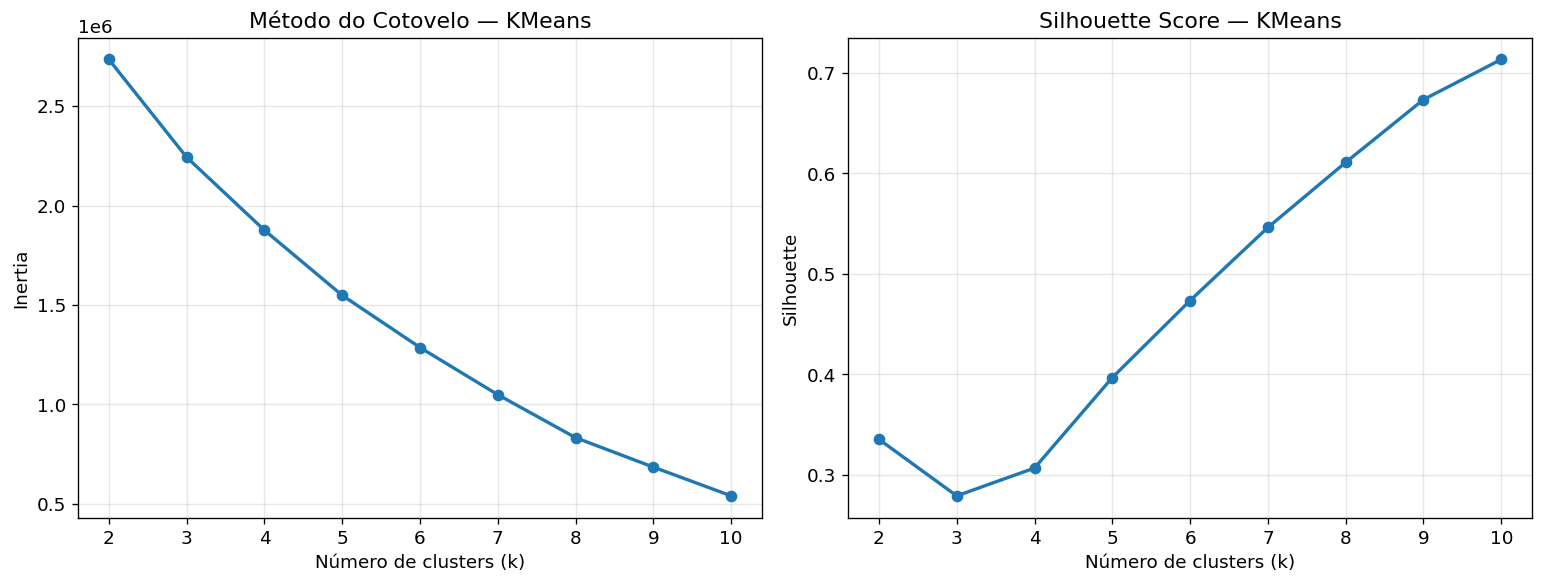

In [26]:
# ── 10.2  Visualização do método do cotovelo e silhouette ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_values), inertias, marker='o', lw=2)
axes[0].set_title('Método do Cotovelo — KMeans')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_values))

axes[1].plot(list(k_values), silhouettes, marker='o', lw=2)
axes[1].set_title('Silhouette Score — KMeans')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()


**Leitura do resultado:** A curva de inertia diminui continuamente à medida que k aumenta, como é esperado no KMeans, mas não apresenta um cotovelo muito marcado. Assim, a decisão não deve depender apenas desse gráfico. O silhouette, por outro lado, cresce de forma clara para valores de k mais altos no intervalo testado e favorece k=10.

Como o dataset contém dez compostos, k=10 é uma escolha interpretável para comparar os agrupamentos encontrados com as classes reais. Esta escolha é reforçada pelo silhouette, mas deve ser apresentada com cautela: o teste foi feito apenas entre k=2 e k=10, e o objetivo aqui é avaliar se os dez compostos têm assinaturas espectrais suficientemente distintas para emergirem como grupos.


In [27]:
# ── 10.3  Modelo final de KMeans ─────────────────────────────────────────────
# Como existem 10 compostos no grupo, k=10 é uma escolha natural para comparar com as classes reais.
# Ainda assim, a tabela anterior permite verificar se este k é coerente com a estrutura dos dados.

K_FINAL = 10
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster)

sil_final = silhouette_score(X_cluster, cluster_labels)
ari_final = adjusted_rand_score(y, cluster_labels)
nmi_final = normalized_mutual_info_score(y, cluster_labels)

print(f"KMeans final com k={K_FINAL}")
print(f"Silhouette Score              : {sil_final:.3f}")
print(f"Adjusted Rand Index vs classes: {ari_final:.3f}")
print(f"NMI vs classes reais          : {nmi_final:.3f}")


KMeans final com k=10
Silhouette Score              : 0.713
Adjusted Rand Index vs classes: 0.860
NMI vs classes reais          : 0.929


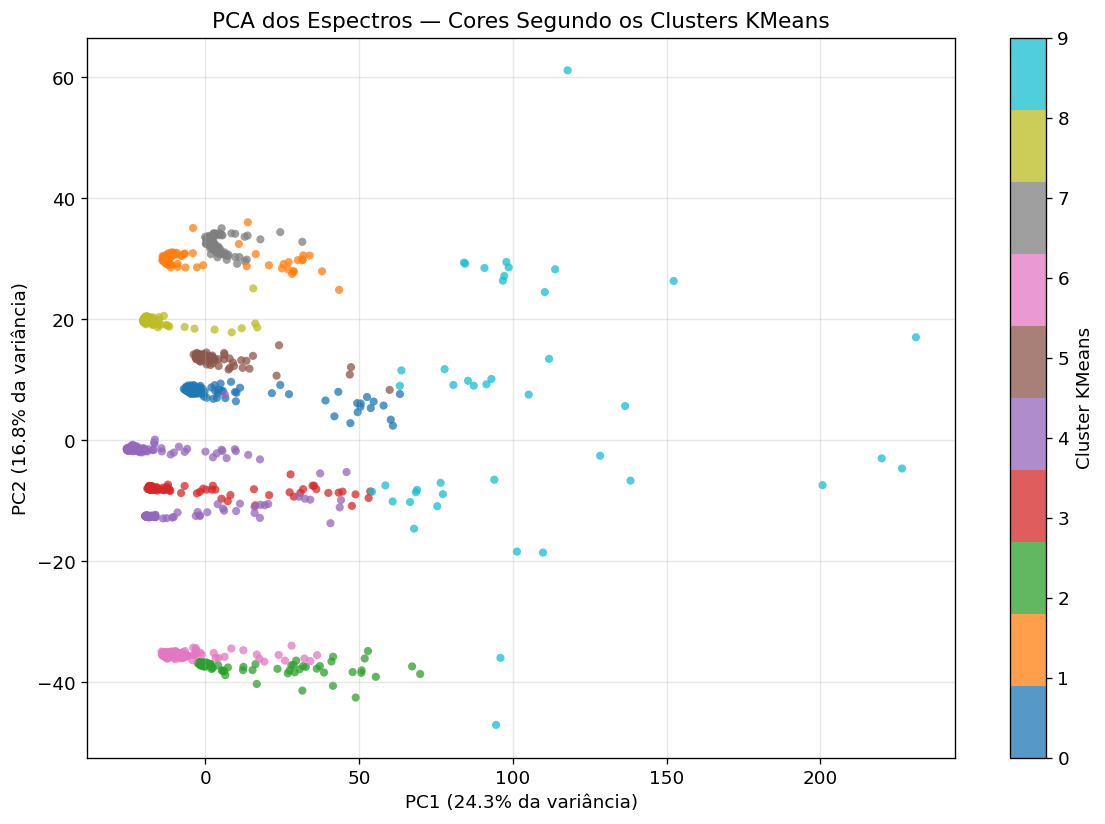

In [28]:
# ── 10.4  PCA colorido pelos clusters obtidos ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='tab10',
    s=24,
    alpha=0.75,
    edgecolor='none'
)

ax.set_title('PCA dos Espectros — Cores Segundo os Clusters KMeans', fontsize=13)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% da variância)")
plt.colorbar(scatter, ax=ax, label='Cluster KMeans')

plt.tight_layout()
plt.show()


In [29]:
# ── 10.5  Comparação entre clusters e compostos reais ─────────────────────────
cluster_comparison = pd.crosstab(
    pd.Series(y, name='Composto real'),
    pd.Series(cluster_labels, name='Cluster KMeans')
)

print("Tabela de correspondência entre compostos reais e clusters:")
print()
print(cluster_comparison.to_string())


Tabela de correspondência entre compostos reais e clusters:

Cluster KMeans                    0    1    2    3    4   5    6   7    8   9
Composto real                                                                
1,3-Dimethyl-2-imidazolidinone  109    0    0    0    0   0    0   0    0   0
2,2-Dimethoxypropane              0    0    0    0    0  95    0   0    0  12
2-Propanol                        0    0    0    0    0   0    0  97    0  12
4-Methyl-2-pentanone              0  100    0    0    0   0    0   0    0   0
Acetic acid                       0    0    0  107    0   0    0   0    0   6
Acetone                           0    0    0    0  120   0    0   0    0   0
Acetonitrile                      0    0    0    0   93   0    0   0    0  11
Benzaldehyde                      0    0  119    0    0   0    0   0    0   2
Benzyl bromide                    0    0    0    0    0   0  112   0    0   0
Butyl acetate                     0    0    0    0    0   0    0   0  106   0


In [30]:
# ── 10.6  Composição principal de cada cluster ───────────────────────────────
cluster_summary_rows = []

for cluster_id in sorted(np.unique(cluster_labels)):
    mask = (cluster_labels == cluster_id)
    values, counts = np.unique(y[mask], return_counts=True)
    order = np.argsort(counts)[::-1]
    
    main_compound = values[order[0]]
    main_count = counts[order[0]]
    total = counts.sum()
    purity = main_count / total
    
    cluster_summary_rows.append({
        'Cluster': cluster_id,
        'N amostras': int(total),
        'Composto dominante': main_compound,
        'Amostras do composto dominante': int(main_count),
        'Pureza aproximada': round(purity, 3)
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows).set_index('Cluster')
print("Resumo da composição dos clusters:")
print()
print(cluster_summary_df.to_string())


Resumo da composição dos clusters:

         N amostras              Composto dominante  Amostras do composto dominante  Pureza aproximada
Cluster                                                                                               
0               109  1,3-Dimethyl-2-imidazolidinone                             109              1.000
1               100            4-Methyl-2-pentanone                             100              1.000
2               119                    Benzaldehyde                             119              1.000
3               107                     Acetic acid                             107              1.000
4               213                         Acetone                             120              0.563
5                95            2,2-Dimethoxypropane                              95              1.000
6               112                  Benzyl bromide                             112              1.000
7                97                  

**Interpretação:** A análise por KMeans deve ser lida em conjunto com dois elementos: o gráfico de avaliação de k e a comparação entre clusters e compostos reais. No gráfico do cotovelo, a inertia diminui de forma contínua, sem um ponto de quebra muito abrupto. Por isso, o cotovelo sozinho não define de forma inequívoca o número ideal de grupos. Já o silhouette aumenta claramente para valores mais altos de k dentro do intervalo testado, atingindo o melhor resultado em k=10.

A escolha de k=10 é, portanto, coerente com dois aspetos: há dez compostos no conjunto de dados e o silhouette favorece essa solução no intervalo analisado. Ainda assim, esta decisão não deve ser apresentada como uma prova absoluta de que só existem dez estruturas naturais nos dados; deve ser apresentada como uma escolha adequada para comparar os grupos encontrados com os dez compostos reais.

No gráfico PCA colorido pelos clusters, vários grupos aparecem compactos e espacialmente separados. Também se observa pelo menos um cluster mais disperso ao longo da PC1, o que sugere maior variabilidade interna ou separação dependente de componentes que não são totalmente visíveis no plano PC1–PC2. Como o KMeans foi ajustado com as primeiras componentes principais e não apenas com as duas do gráfico, a visualização 2D deve ser interpretada como uma projeção resumida, não como a totalidade da decisão do algoritmo.


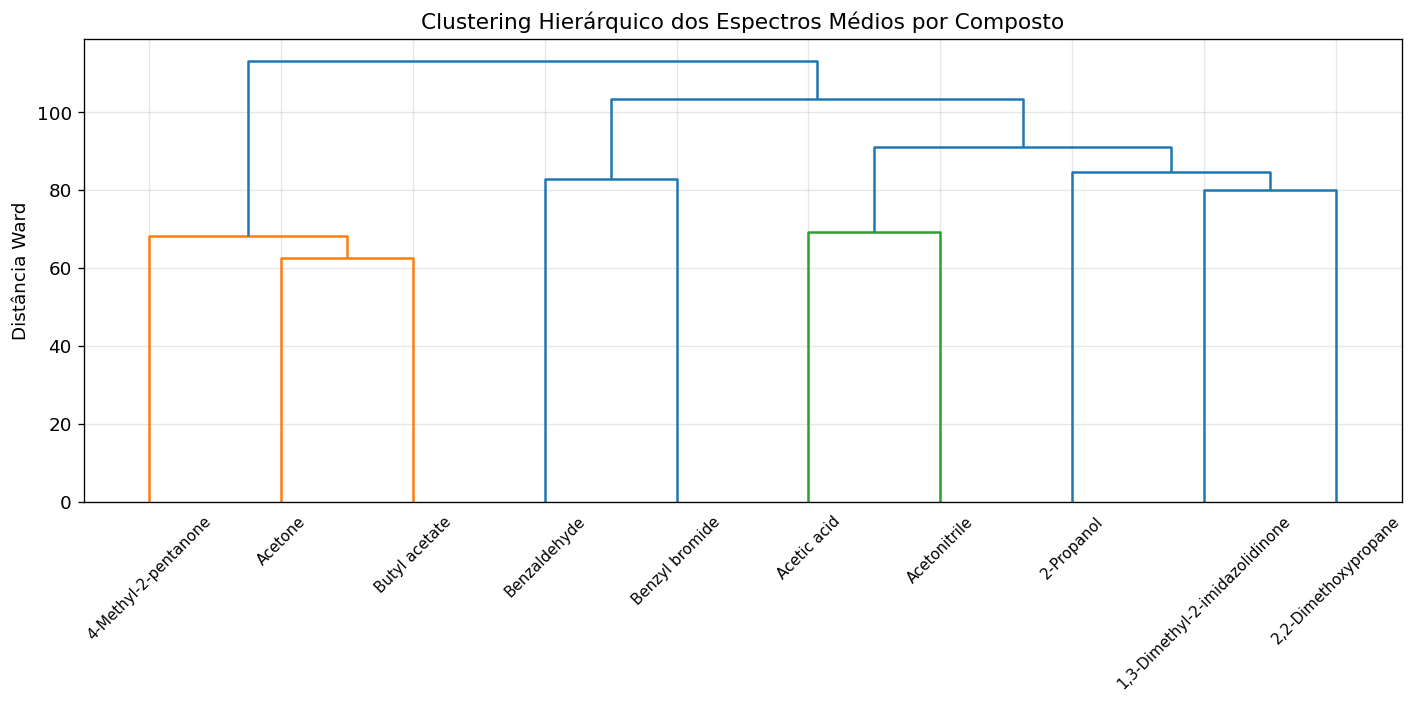

In [31]:
# ── 10.7  Clustering hierárquico dos espectros médios por composto ────────────
# Aqui usamos o espectro médio de cada composto para perceber relações globais entre substâncias.

mean_matrix = np.vstack([mean_spectra[compound] for compound in compounds])
mean_matrix_scaled = StandardScaler().fit_transform(mean_matrix)

Z = linkage(mean_matrix_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    labels=compounds,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax
)
ax.set_title('Clustering Hierárquico dos Espectros Médios por Composto', fontsize=13)
ax.set_ylabel('Distância Ward')

plt.tight_layout()
plt.show()


**Interpretação:** O dendrograma permite interpretar a semelhança global entre os espectros médios dos compostos. Um resultado particularmente coerente é a proximidade entre a Acetona e a 4-Metil-2-pentanona, que são cetonas alifáticas e partilham características espectrais associadas ao grupo carbonilo e ao esqueleto hidrocarbonado. O Acetato de butilo surge próximo deste ramo, o que é compatível com o facto de também conter carbonilo, embora pertença a outra família funcional.

Outro agrupamento interpretável é o do Benzaldeído com o Brometo de benzilo. Apesar de terem grupos funcionais diferentes, ambos contêm uma estrutura aromática, o que pode explicar a proximidade dos seus espectros médios, especialmente nas zonas associadas a vibrações do anel.

O ramo que aproxima o Ácido acético e o Acetonitrilo deve ser interpretado com maior prudência, porque a semelhança não corresponde diretamente a uma mesma família funcional. Neste caso, a proximidade pode resultar mais da forma global dos espectros pré-processados e da intensidade relativa de certas bandas do que de uma semelhança química simples. O mesmo cuidado se aplica ao agrupamento envolvendo o 2-Propanol, a 1,3-Dimetil-2-imidazolidinona e o 2,2-Dimetoxipropano: a árvore mostra proximidade espectral média, mas não implica que estes compostos tenham a mesma classe química.

Assim, o dendrograma é útil porque evidencia relações entre assinaturas Raman completas, mas não deve ser reduzido apenas à presença ou ausência de um grupo funcional isolado.


---

## 11. Interpretação Química dos Resultados Multivariados

A análise multivariada confirma que os espectros Raman do Grupo 4 contêm informação suficiente para revelar padrões de separação entre os compostos, mesmo sem usar as etiquetas durante o clustering. A região fingerprint tem um papel central nesta distinção, porque concentra várias vibrações sensíveis à estrutura molecular.

Nos espectros médios, os compostos aromáticos distinguem-se por bandas marcadas em regiões compatíveis com vibrações do anel, o que ajuda a explicar a proximidade entre o Benzaldeído e o Brometo de benzilo no dendrograma. Esta proximidade não significa que os compostos tenham a mesma função química, mas mostra que a componente aromática tem peso importante na assinatura Raman média.

As cetonas alifáticas, como a Acetona e a 4-Metil-2-pentanona, aparecem próximas no clustering hierárquico, o que é consistente com a partilha do grupo carbonilo e de uma estrutura alifática. A presença do Acetato de butilo no mesmo ramo deve ser interpretada de forma moderada: o composto também contém um grupo carbonilo, mas a ligação é de éster e a restante estrutura molecular é diferente. Assim, a proximidade pode refletir bandas comuns e não uma identidade química completa.

O PCA mostra que uma parte importante da separação ocorre logo nas duas primeiras componentes, mas também mostra que há dispersão interna em alguns compostos. Isto é esperado em dados Raman reais, porque pequenas diferenças no perfil espectral, no pré-processamento ou na intensidade relativa dos picos podem deslocar amostras no espaço multivariado. Por essa razão, a interpretação mais segura é dizer que o PCA evidencia tendências de separação, enquanto o clustering e o dendrograma ajudam a confirmar relações mais globais entre os espectros.

Em termos químicos, os resultados indicam que a separação dos compostos não depende de uma única banda isolada. O padrão observado resulta da combinação entre grupos funcionais, estrutura aromática ou alifática, posição dos picos e forma global do espectro. Esta é precisamente a vantagem da abordagem multivariada: usar o espectro completo para encontrar relações que seriam difíceis de resumir apenas por inspeção visual.

---

## 12. Conclusão da Análise Não Supervisionada

A análise não supervisionada permitiu passar de uma comparação visual dos espectros para uma leitura estatística da semelhança entre compostos. A comparação dos espectros médios mostrou diferenças claras na região fingerprint, com picos e padrões de intensidade que variam de forma relevante entre substâncias.

O PCA resumiu os espectros em componentes principais e mostrou que as duas primeiras componentes já permitem observar várias tendências de separação. No entanto, como estas componentes não representam toda a variabilidade dos dados, a interpretação do gráfico 2D deve ser feita com cuidado. A utilização de mais componentes no clustering é adequada porque preserva informação adicional que não aparece totalmente no plano PC1–PC2.

O KMeans com k=10 apresentou uma solução coerente com o número de compostos e com a evolução do silhouette no intervalo analisado. Ainda assim, a escolha de k deve ser justificada como uma combinação entre critério estatístico e conhecimento do dataset, e não apenas como uma decisão automática. O clustering hierárquico dos espectros médios acrescentou uma leitura química útil, destacando relações como a proximidade entre cetonas alifáticas e entre compostos aromáticos.

No conjunto, os resultados indicam que os espectros Raman pré-processados preservam informação química suficiente para distinguir grande parte dos compostos do Grupo 4. As diferenças observadas estão associadas à assinatura espectral completa: região fingerprint, bandas de grupos funcionais, contribuição aromática ou alifática e intensidade relativa dos picos. Esta análise fornece uma base sólida para a etapa seguinte, em que modelos supervisionados podem ser usados para testar quantitativamente a capacidade de classificação dos compostos.

---
## 13. Análise Preditiva e Machine Learning

Nesta secção, o objetivo é construir modelos preditivos capazes de classificar corretamente as amostras entre os 10 compostos do nosso grupo, com base nos espectos de Raman Shifts.

Para garantir uma análise robusta, seguiremos estes passos:

 **1. Comparação de três modelos distintos**:

  - Random Forest: Baseado em árvores de decisão, imune à escala e excelente para seleção de features.

  - Support Vector Machine (SVM): Excelente para lidar com dados de alta dimensionalidade.

  - Regressão Logística: Um modelo linear eficiente para classificação baseada em probabilidade.

 **2. Validação dos modelos**: Utilizando um split de treino/teste estratificado e avaliando com métricas adequadas (Accuracy, F1-Score e Matriz de Confusão).

 **3. Interpretação das Variáveis**: Extração da importância das variáveis (quando aplicável ao modelo) e correlação das features (Raman Shifts) com a estrutura química dos compostos (ex: ligações C=O ou anéis aromáticos).

### 13.1 Preparação do dataset para os modelos

In [32]:
# Preparação dos dados
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.3, random_state=42, stratify=y)

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definição dos Modelos
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42)
}

# Treino
trained_models = {} # Novo dicionário para guardar os modelos já treinados
print("A iniciar o treino dos modelos")

for name, model in models.items():
    # Para o RF usamos os dados normais, para os modelos lineares usamos os escalonados
    if name == "Random Forest":
        model.fit(X_train, y_train)
    else:
        model.fit(X_train_scaled, y_train)
    
    # Guardar modelo treinado
    trained_models[name] = model
    print(f"[{name}] treinado com sucesso.")

A iniciar o treino dos modelos
[Random Forest] treinado com sucesso.
[SVM (Linear)] treinado com sucesso.
[Regressão Logística] treinado com sucesso.


In [33]:
# Avaliação e Teste Final
results = {}

print("A avaliar o desempenho nos dados de teste...\n")

# Iterar sobre os modelos que foram treinados na Célula 1
for name, model in trained_models.items():
    
    # Decidir qual o conjunto de dados a usar para a previsão com base no nome do modelo
    if name == "Random Forest":
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"Accuracy": acc, "Predictions": y_pred, "Model": model}
    
    # Imprimir os resultados
    print(f"--- Desempenho: {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 35 + "\n")

A avaliar o desempenho nos dados de teste...

--- Desempenho: Random Forest ---
Accuracy: 0.9909
                                precision    recall  f1-score   support

1,3-Dimethyl-2-imidazolidinone       1.00      1.00      1.00        33
          2,2-Dimethoxypropane       1.00      1.00      1.00        32
                    2-Propanol       1.00      1.00      1.00        33
          4-Methyl-2-pentanone       0.97      1.00      0.98        30
                   Acetic acid       1.00      0.97      0.99        34
                       Acetone       1.00      1.00      1.00        36
                  Acetonitrile       0.94      1.00      0.97        31
                  Benzaldehyde       1.00      0.97      0.99        36
                Benzyl bromide       1.00      1.00      1.00        34
                 Butyl acetate       1.00      0.97      0.98        32

                      accuracy                           0.99       331
                     macro avg       

**Interpretação**: Os resultados revelam um desempenho excecional de todos os três modelos na classificação dos compostos químicos, o que indica que as assinaturas espectrais destes materiais são altamente distintas e de fácil identificação.

O SVM Linear destacou-se claramente como o melhor modelo, alcançando uma exatidão absoluta (100%) em todas as métricas (precision, recall, f1-score) e para todas as classes, sem cometer qualquer erro de previsão. A Regressão Logística obteve um resultado quase perfeito, com uma exatidão de 99.70%, falhando de forma quase impercetível numa única classificação residual. Por sua vez, o Random Forest, apesar de ter sido o algoritmo com a exatidão comparativamente mais baixa (99.09%), manteve um desempenho global excelente, registando apenas ligeiras dificuldades em instâncias pontuais.

De forma geral, o excelente desempenho dos modelos demonstra que este problema de classificação é de natureza linearmente separável. Dada a sua exatidão absoluta, o SVM Linear aparenta possivelmente ser a melhor escolha de algoritmo, dado que foi o mais fiável e exato para a classificação deste conjunto de dados.

### 13.3 Validação e Discussão das Matrizes de Confusão

As métricas globais (Accuracy e F1-Score) dão-nos uma visão geral do desempenho, mas as matrizes de confusão permitem-nos fazer uma discussão mais aprofundada sobre quais os compostos são mais fáceis ou difíceis de distinguir. Abaixo, são apresentadas as matrizes resultantes para os três modelos avaliados (Random Forest, Regressão Logística e SVM Linear).

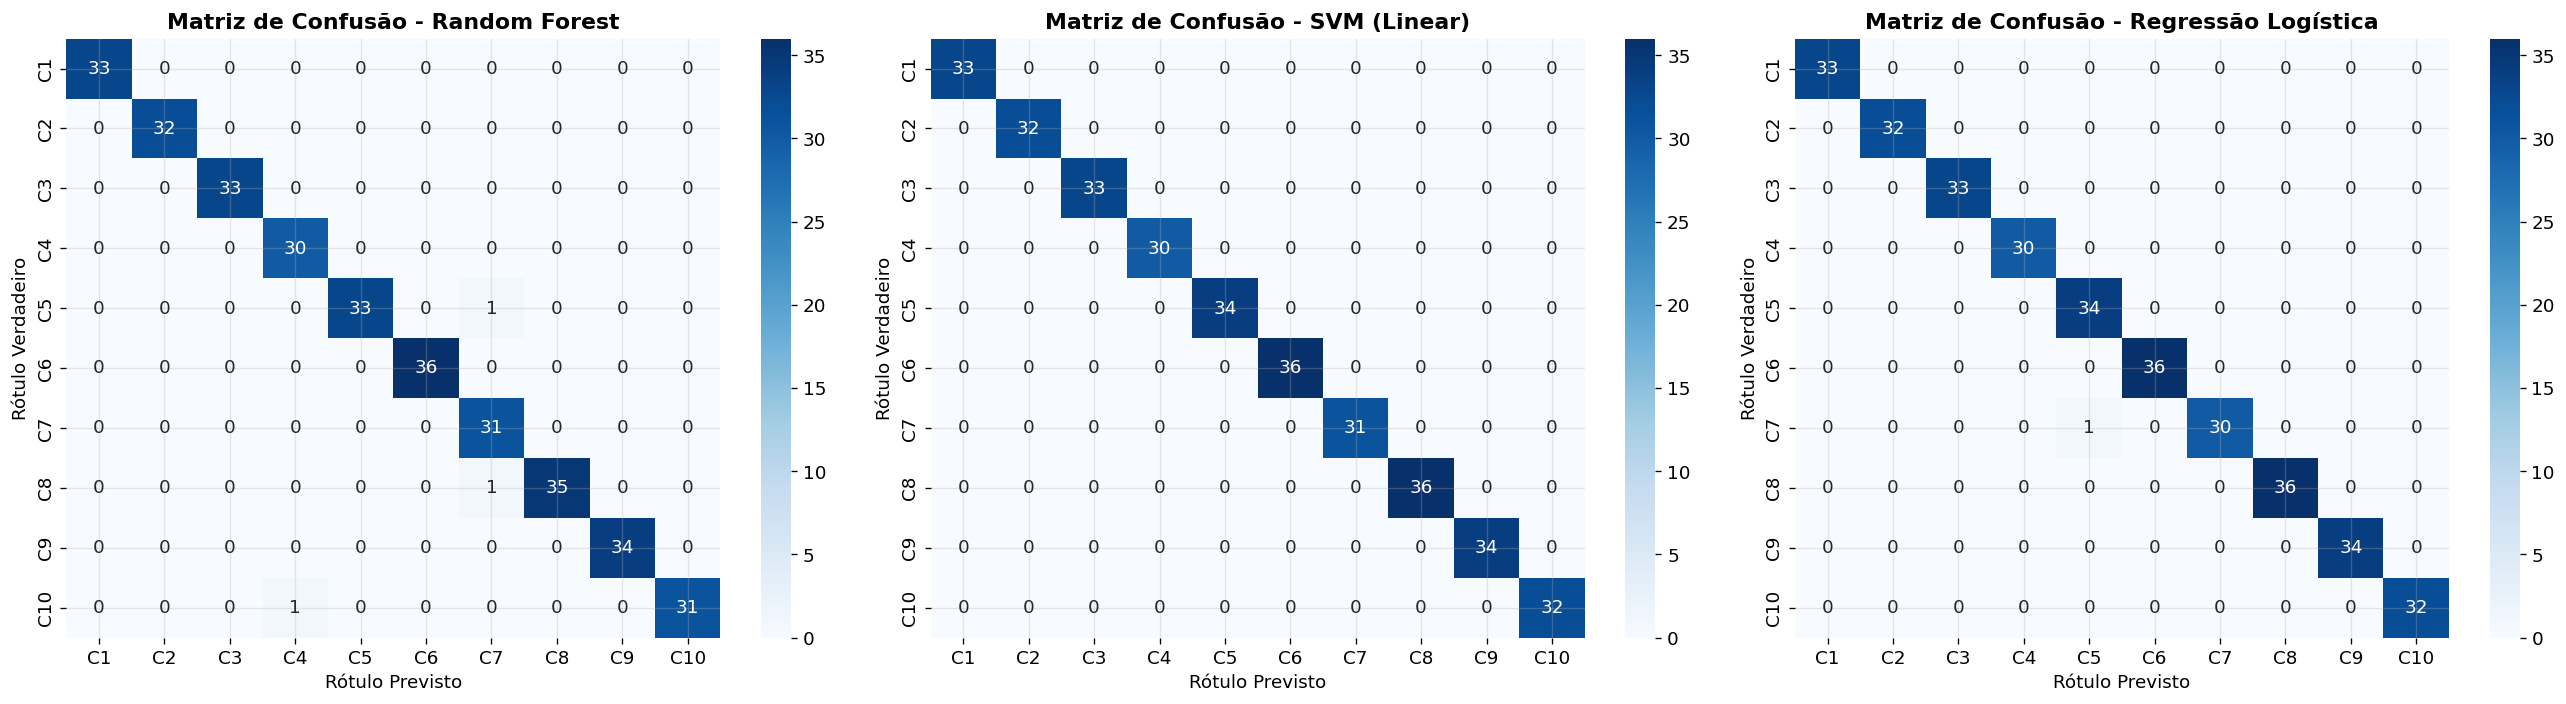

Legenda dos compostos:
C1: 1,3-Dimethyl-2-imidazolidinone
C2: 2,2-Dimethoxypropane
C3: 2-Propanol
C4: 4-Methyl-2-pentanone
C5: Acetic acid
C6: Acetone
C7: Acetonitrile
C8: Benzaldehyde
C9: Benzyl bromide
C10: Butyl acetate


In [34]:
# Definir labels curtas baseadas no número de classes únicas
unique_labels = np.unique(y)
n_classes = len(unique_labels)
labels_curtos = [f"C{i+1}" for i in range(n_classes)]

# Criar a figura
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result["Predictions"])
    
    # Gerar o heatmap com as labels curtas
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_curtos, yticklabels=labels_curtos)
    
    ax.set_title(f'Matriz de Confusão - {name}', fontweight='bold')
    ax.set_ylabel('Rótulo Verdadeiro')
    ax.set_xlabel('Rótulo Previsto')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Cria um dicionário para referência
mapeamento = {f"C{i+1}": composto for i, composto in enumerate(unique_labels)}

print("Legenda dos compostos:")
for k, v in mapeamento.items():
    print(f"{k}: {v}")

**Interpretação:** A análise das matrizes de confusão revela que os erros de classificação estão diretamente ligados à estrutura química dos compostos e à qualidade da medição das amostras.

No caso do Random Forest, o modelo cometeu o seu primeiro erro ao confundir uma amostra de acetato de butilo com a 4-metil-2-pentanona. Isto é perfeitamente justificável sob o ponto de vista químico: ambas partilham uma forte semelhança estrutural (cadeias alifáticas e um grupo carbonilo), o que origina espetros Raman altamente sobrepostos e dificulta a distinção matemática.

O segundo erro do Random Forest consistiu em falhar duas amostras de acetonitrilo, prevendo-as como benzaldeído e ácido acético. Como estes três compostos são quimicamente muito distintos, o modelo provavelmente não os confundiu por serem parecidos. O erro ocorreu, muito provavelmente, devido a defeitos de medição naquelas amostras específicas, como ruído do equipamento. Como este algoritmo decide olhando apenas para pontos muito restritos do espetro, bastou que esse ruído calhasse exatamente num desses pontos para gerar uma classificação errada, por exemplo.

Na Regressão Logística, o modelo apresentou um desempenho quase imaculado, errando apenas ao classificar uma amostra de acetonitrilo como ácido acético. Como os compostos são quimicamente muito distintos, esta falha provavelmente não resulta de uma semelhança intrínseca entre as moléculas, mas sim de um potencial erro causado pela presença de ruído localizado na medição daquela amostra específica. Uma vez que o modelo avalia todo o espetro de forma linear, a ocorrência de ruído instrumental em frequências às quais o algoritmo atribui maior peso para a deteção do ácido acético pode acabar por enviesar o cálculo matemático, levando a uma classificação incorreta.

Por fim, o SVM Linear destacou-se com um comportamento perfeito, sem registo de qualquer erro de classificação. Este resultado valida que as diferentes moléculas são integralmente separáveis. Ao analisar os espetros na sua totalidade (de forma holística), o algoritmo SVM consolida-se como a ferramenta mais robusta para resolver este problema, conseguindo distinguir as substâncias mais semelhantes sem ceder aos pequenos ruídos que enviesaram os outros modelos.

### 13.4 Seleção de Variáveis e Interpretação Química/Espetroscópica

Uma das grandes vantagens da utilização de modelos interpretáveis de Machine Learning na espetroscopia Raman é a capacidade de compreender os critérios por trás da classificação. Os modelos não processam o espetro de forma homogénea; pelo contrário, procuram as regiões de maior variância e poder discriminativo. Através de métricas como a "Importância das Variáveis" no Random Forest ou a magnitude dos coeficientes no SVM Linear, é possível identificar com precisão os números de onda (Raman shifts) determinantes para o algoritmo. O objetivo desta secção é cruzar esta seleção matemática de variáveis com a teoria espetroscópica, demonstrando que os modelos aprenderam a focar-se nas impressões digitais químicas (grupos funcionais) que distinguem efetivamente as moléculas.

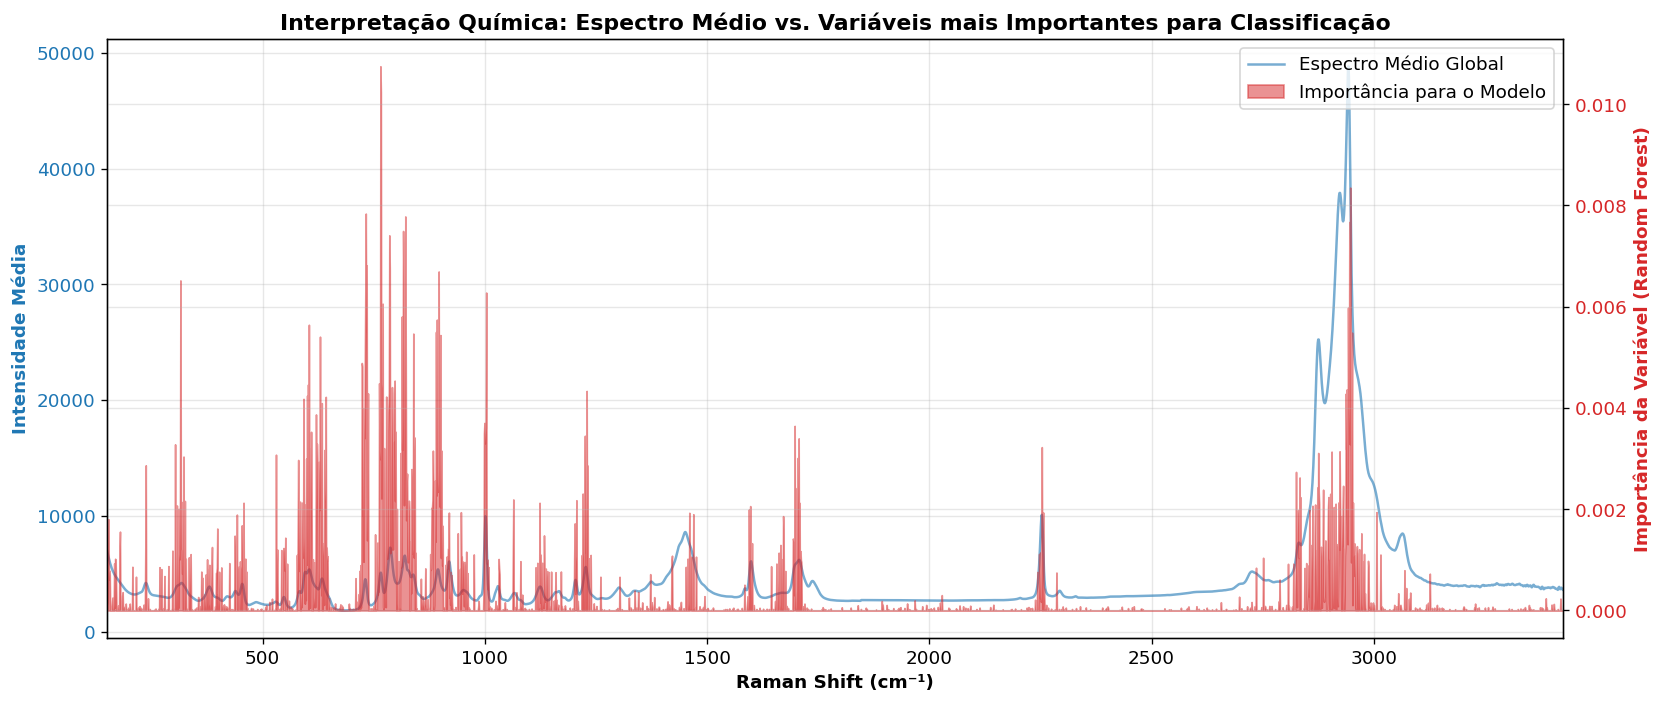

Top 10 Raman Shifts mais importantes para o Modelo (cm⁻¹):
765.0 cm⁻¹ (Importância: 0.0107)
766.0 cm⁻¹ (Importância: 0.0102)
2947.0 cm⁻¹ (Importância: 0.0084)
732.0 cm⁻¹ (Importância: 0.0078)
821.0 cm⁻¹ (Importância: 0.0078)
2945.0 cm⁻¹ (Importância: 0.0077)
816.0 cm⁻¹ (Importância: 0.0075)
785.0 cm⁻¹ (Importância: 0.0074)
734.0 cm⁻¹ (Importância: 0.0068)
786.0 cm⁻¹ (Importância: 0.0068)


In [35]:
# Obter as importâncias do Random Forest
rf_model = results["Random Forest"]["Model"]
importances = rf_model.feature_importances_

# 3276 pontos espectrais que vão de 150 a 3425 cm⁻¹
raman_shifts = np.linspace(150, 3425, 3276)

# Calcular o espectro médio usando a função nativa do NumPy
mean_spectrum = np.mean(X_clean, axis=0)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Espectro Médio (Linha Azul)
color = 'tab:blue'
ax1.set_xlabel('Raman Shift (cm⁻¹)', fontweight='bold')
ax1.set_ylabel('Intensidade Média', color=color, fontweight='bold')
ax1.plot(raman_shifts, mean_spectrum, color=color, label='Espectro Médio Global', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: Importância das Variáveis (Barras Vermelhas) no Eixo Y secundário
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Importância da Variável (Random Forest)', color=color, fontweight='bold')
# Usamos fill_between para parecerem picos de importância
ax2.fill_between(raman_shifts, 0, importances, color=color, alpha=0.5, label='Importância para o Modelo')
ax2.tick_params(axis='y', labelcolor=color)

# Juntar legendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Interpretação Química: Espectro Médio vs. Variáveis mais Importantes para Classificação', fontweight='bold')
plt.xlim(raman_shifts.min(), raman_shifts.max())
plt.tight_layout()
plt.show()

# Imprimir o top 10 das bandas mais importantes
top_indices = np.argsort(importances)[::-1][:10]
top_shifts = raman_shifts[top_indices]
print("Top 10 Raman Shifts mais importantes para o Modelo (cm⁻¹):")
for shift, imp in zip(top_shifts, importances[top_indices]):
    print(f"{shift:.1f} cm⁻¹ (Importância: {imp:.4f})")

**Interpretação:**
A análise do gráfico de importâncias e das dez variáveis mais determinantes revela que o
modelo não baseou a sua classificação na intensidade máxima global do sinal espetral,
focando-se, em vez disso, na identificação de marcadores químicos altamente específicos.
O algoritmo atribuiu o peso máximo a duas regiões fundamentais: uma zona muito restrita
da região de impressão digital, compreendida entre os 730 e os 825 cm⁻¹, e uma segunda
região de alta frequência, localizada entre os 2943 e os 2947 cm⁻¹, dominada por
estiramentos C-H.

Na primeira região, os picos de maior relevância, situados entre os 765 e os 766 cm⁻¹,
correspondem diretamente à assinatura vibracional característica da
1,3-dimetil-2-imidazolidinona. Da mesma forma, as variáveis na faixa dos 732 a 734 cm⁻¹
alinham-se com a banda de deformação do 2,2-dimetoxipropano. Cruzando estes dados com
os valores teóricos das bandas Raman, conclui-se que as zonas espectrais entre os 785 e
os 786 cm⁻¹ e entre os 816 e os 821 cm⁻¹ são cruciais para discriminar compostos com
características estruturais próximas: a primeira coincide com uma banda da
4-metil-2-pentanona (MIBK), enquanto a segunda corresponde a uma banda de
2-propanol (IPA), permitindo ao modelo separar estas cetonas e álcoois alifáticos de
forma inequívoca.

Em paralelo, a seleção das variáveis nos 2943 e nos 2947 cm⁻¹ demonstra a capacidade
do algoritmo em utilizar características de suporte para refinar a sua decisão. A
frequência de 2947 cm⁻¹ confirma a presença do 2,2-dimetoxipropano, cuja banda C-H
é tabelarmente conhecida nessa posição, enquanto a frequência adjacente de 2943 cm⁻¹
funciona como limiar de decisão para identificar o ácido acético, composto que
apresenta uma banda C-H característica nessa região.

Em suma, o modelo comportou-se como um intérprete espetroscópico altamente seletivo.
Ao ignorar o ruído de fundo e as frequências de espalhamento comuns a várias moléculas,
o algoritmo isolou com precisão os números de onda que correspondem aos grupos
funcionais e às vibrações moleculares mais distintivas de cada composto. Isto demonstra
que as variáveis de maior peso estatístico não resultam do acaso, possuindo uma
justificação química direta e rigorosa, perfeitamente alinhada com a teoria vibracional
dos compostos analisados.

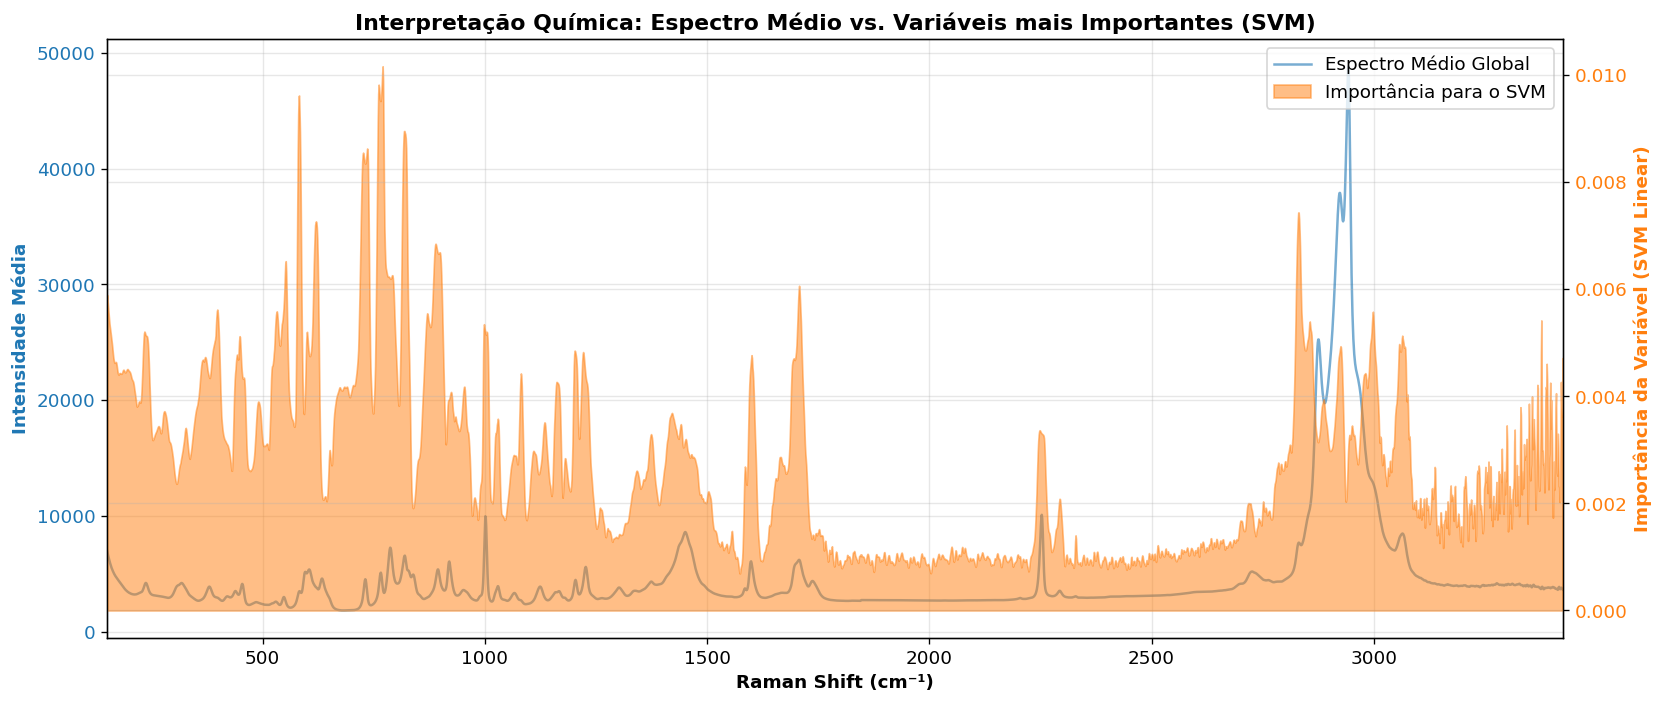

In [36]:
# Obter os coeficientes do SVM
svm_model = results["SVM (Linear)"]["Model"]
coefs = svm_model.coef_

# Calcular a importância: Média do valor absoluto (para ver a magnitude da influência)
svm_importances = np.abs(coefs).mean(axis=0)

# 3. Criar o gráfico (o código é quase idêntico ao do Random Forest)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Espectro Médio
color = 'tab:blue'
ax1.set_xlabel('Raman Shift (cm⁻¹)', fontweight='bold')
ax1.set_ylabel('Intensidade Média', color=color, fontweight='bold')
ax1.plot(raman_shifts, mean_spectrum, color=color, label='Espectro Médio Global', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: Importância das Variáveis do SVM
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Importância da Variável (SVM Linear)', color=color, fontweight='bold')
ax2.fill_between(raman_shifts, 0, svm_importances, color=color, alpha=0.5, label='Importância para o SVM')
ax2.tick_params(axis='y', labelcolor=color)

# Legendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Interpretação Química: Espectro Médio vs. Variáveis mais Importantes (SVM)', fontweight='bold')
plt.xlim(raman_shifts.min(), raman_shifts.max())
plt.tight_layout()
plt.show()

**Interpretação:**
Ao contrário do Random Forest, que concentrou o seu poder discriminativo em bandas muito
pontuais, o SVM Linear adotou uma estratégia significativamente mais distribuída, atribuindo
coeficientes de importância ao longo de praticamente todo o intervalo espetral medido. Contudo,
esta distribuição não é uniforme: a análise do gráfico revela que as regiões de maior peso
matemático se concentram sobretudo na zona de impressão digital (400–1000 cm⁻¹), onde se
encontram as vibrações esqueletais e de deformação que tornam cada molécula quimicamente
única. É de notar que esta região apresenta intensidade média relativamente baixa no espetro
global, o que demonstra que o SVM não se limitou a reagir à intensidade do sinal, aprendendo
antes a valorizar os marcadores com maior poder discriminativo independentemente da sua
magnitude absoluta.

Na região dos estiramentos C-H (~2900–3100 cm⁻¹), onde o espetro médio global regista as
suas intensidades mais elevadas, a importância atribuída pelo SVM é apenas moderada. Este
comportamento é quimicamente coerente: as vibrações C-H são comuns à quase totalidade dos
compostos em estudo, pelo que constituem um mau discriminador entre classes e o modelo
aprendeu, corretamente, a desvalorizar essa região.

Em suma, a força do SVM Linear reside na sua capacidade de integrar a totalidade da assinatura
espetral de forma ponderada, explorando a complementaridade entre múltiplas regiões em vez de
depender de um punhado de picos isolados. Esta visão global e simultaneamente seletiva é
provavelmente o fator determinante para o desempenho superior deste modelo na classificação
dos compostos analisados.

## 13.5 Limitações dos Modelos e Considerações Finais
Embora os modelos aplicados tenham demonstrado um desempenho excecional, culminando na
classificação perfeita do modelo SVM Linear (100% de exatidão), uma análise rigorosa exige
a identificação das limitações metodológicas e contextuais deste trabalho:

 - **Risco de Overfitting e Condições Ideais:**
 A exatidão de 100% obtida pelo SVM Linear sugere que o problema é perfeitamente separável
 de forma linear, o que é um resultado notável. Contudo, importa referir que os espectros
 provieram de um único dataset. Se testássemos estes mesmos modelos com dados recolhidos
 num equipamento Raman diferente, com uma outra calibração, resoluções distintas ou maior
 ruído de fluorescência, a eficácia preditiva poderia decair. Para avaliar a verdadeira
 capacidade de generalização do modelo, será necessário testá-lo com amostras de múltiplas
 origens físicas e instrumentais.

 - **Estratégia de Validação:**
 Neste estudo, a validação foi efetuada através de uma divisão simples dos dados em conjuntos
 de treino e teste (train-test split). Como limitação inerente a conjuntos de dados de dimensões
 mais reduzidas, sabemos que uma partição particularmente favorável pode inflacionar as métricas
 de sucesso. A aplicação de uma validação cruzada com múltiplos subconjuntos (k-fold
 cross-validation) seria uma abordagem recomendável para garantir uma robustez do modelo
 totalmente independente da forma como a amostragem é dividida.

 - **Otimização de Hiperparâmetros (Tuning):**
 Os algoritmos aplicados utilizaram, na sua maioria, as configurações padrão das bibliotecas,
 sem recurso a metodologias exaustivas de pesquisa, como o GridSearchCV ou o
 RandomizedSearchCV. Uma vez que os resultados atingiram níveis de previsão quase perfeitos
 (99% a 100%), considerou-se que o aumento do custo computacional associado a uma otimização
 exaustiva não se justificava. Embora um ajuste mais fino dos hiperparâmetros pudesse ser
 implementado, os ganhos práticos no desempenho seriam marginais, dada a elevada precisão
 intrínseca já revelada pelos modelos.

**Conclusão:**

Em suma, a aplicação de algoritmos de Machine Learning evidenciou que a espectroscopia Raman
produz assinaturas moleculares de elevada fiabilidade. A adoção combinada de práticas de
pré-processamento, como a correção da linha de base e a suavização do sinal, suportou de forma
decisiva o sucesso da modelação. Mais do que simplesmente memorizar padrões numéricos, os
modelos matemáticos aparentam ter aprendido a reconhecer grupos funcionais, possivelmente como
as ligações C=O, os anéis aromáticos e as ligações C≡N, que são característicos dos compostos
em estudo, com base nos espectros Raman.